# Import Libraries and packages

In [2]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(
    { "figure.figsize": (8, 5) },
    style='ticks',
    color_codes=True,
    font_scale=1
)
%config InlineBackend.figure_format = 'retina'

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

!pip install category_encoders -q
!pip install xgboost

# ML utilities
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn import metrics

# Models
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans

# Encoding and metrics
from category_encoders import TargetEncoder
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, classification_report

# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Loading the dataset

In [4]:
ecom_data = pd.read_csv("../data/Dataset_ecommerce.csv")

# Initial inspection of the dataset

In [6]:
ecom_data.head()

,InvoiceNo,InvoiceDate,CustomerID,StockCode,Description,Quantity,UnitPrice,Country
0,536365,2010-12-01 08:26:00,17850.0,SC1734,Electronics,65,10.23,Egypt
1,536365,2010-12-01 08:26:00,17850.0,SC2088,Furniture,95,19.61,Mali
2,536365,2010-12-01 08:26:00,17850.0,SC3463,Books,78,61.49,Mali
3,536365,2010-12-01 08:26:00,17850.0,SC6228,Toys,15,24.73,South Africa
4,536365,2010-12-01 08:26:00,17850.0,SC2149,Toys,50,38.83,Rwanda


In [7]:
ecom_data.sample()

,InvoiceNo,InvoiceDate,CustomerID,StockCode,Description,Quantity,UnitPrice,Country
389379,570467,2011-10-10 16:06:00,12607.0,SC7039,Kitchenware,40,70.35,Burkina Faso


In [8]:
ecom_data.shape

(541909, 8)

In [9]:
ecom_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   InvoiceDate  541909 non-null  object 
 2   CustomerID   406829 non-null  float64
 3   StockCode    541909 non-null  object 
 4   Description  541909 non-null  object 
 5   Quantity     541909 non-null  int64  
 6   UnitPrice    541909 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


### Observation: Sampled Dataset contains 541909 rows and 8 columns in which most of them are strings.

In [11]:
ecom_data.describe(include='all')

,InvoiceNo,InvoiceDate,CustomerID,StockCode,Description,Quantity,UnitPrice,Country
count,541909,541909,406829.000000,541909,541909,541909.000000,541909.000000,541909
unique,25900,23260,NaN,9000,10,NaN,NaN,28
top,573585,2011-10-31 14:41:00,NaN,SC2014,Sports Equipment,NaN,NaN,Cote d'Ivoire
freq,1114,1114,NaN,96,54765,NaN,NaN,19651
mean,NaN,NaN,15287.690570,NaN,NaN,50.534748,50.476354,NaN
std,NaN,NaN,1713.600303,NaN,NaN,28.849367,28.564775,NaN
min,NaN,NaN,12346.000000,NaN,NaN,1.000000,1.000000,NaN
25%,NaN,NaN,13953.000000,NaN,NaN,26.000000,25.750000,NaN
50%,NaN,NaN,15152.000000,NaN,NaN,51.000000,50.430000,NaN
75%,NaN,NaN,16791.000000,NaN,NaN,76.000000,75.180000,NaN


In [12]:
# Checking Unique values in the columns
print("Unique Customers:", ecom_data['CustomerID'].nunique())
print("Unique Products:", ecom_data['StockCode'].nunique())
print("Countries:", ecom_data['Country'].nunique())

Unique Customers: 4372
Unique Products: 9000
Countries: 28


In [13]:
ecom_data.isnull().sum()

InvoiceNo           0
InvoiceDate         0
CustomerID     135080
StockCode           0
Description         0
Quantity            0
UnitPrice           0
Country             0
dtype: int64

### Observation - The CustomerID column have 135080 null values (missing data).

# Splitting the features to qualitative and quantitative features

In [16]:
# Categorising quantitative features (numerical columns)
numerical_features = ecom_data.select_dtypes(include=['float64', 'int64']).columns.tolist()
# Categorising qualitative features (categorical columns)
categorical_features = ecom_data.select_dtypes(include=['object', 'bool']).columns.tolist()

In [17]:
numerical_features

['CustomerID', 'Quantity', 'UnitPrice']

In [18]:
categorical_features

['InvoiceNo', 'InvoiceDate', 'StockCode', 'Description', 'Country']

# Data Cleaning & Preprocessing

## Handling missing values, duplicate values and formatting the CustomerID and InvoiceDate 

In [21]:
# the percentage of missing values in each columns
missing_pct = round(ecom_data.isna().sum()/len(ecom_data) * 100, 1)
print(missing_pct)

InvoiceNo       0.0
InvoiceDate     0.0
CustomerID     24.9
StockCode       0.0
Description     0.0
Quantity        0.0
UnitPrice       0.0
Country         0.0
dtype: float64


### Observation - ~25% of the CustomerID values are missing which is a significant portion of the dataset. However, since the goal of the project is churn prediction, it is better to drop rows with missing CustomerID in order to have a clean base of identifiable customers for all the cohort and ML modeling tasks.

In [23]:
# Drop rows with missing CustomerID
ecom_data = ecom_data.dropna(subset=['CustomerID'])

In [24]:
# Confirm if the missing CustomerID are dropped
print(f"Remaining rows: {ecom_data.shape[0]}")
print(f"Missing CustomerID after drop: {ecom_data['CustomerID'].isna().sum()}")

Remaining rows: 406829
Missing CustomerID after drop: 0


In [25]:
# Check number of duplicates before dropping
duplicate_count = ecom_data.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


In [26]:
# Convert the CustomerID from float to integer
ecom_data = ecom_data.dropna(subset=['CustomerID'])
ecom_data['CustomerID'] = ecom_data['CustomerID'].astype(int)

In [27]:
# Convert the date format from string to datetime
ecom_data['InvoiceDate'] = pd.to_datetime(ecom_data['InvoiceDate'])

In [28]:
# check the range of dates
print(ecom_data['InvoiceDate'].min(), "to", ecom_data['InvoiceDate'].max())

2010-12-01 08:26:00 to 2011-12-09 12:50:00


# Feature engineering based on domain knowledge

In [30]:
# Create TotalPrice feature
ecom_data['TotalPrice'] = ecom_data['Quantity'] * ecom_data['UnitPrice']

In [31]:
# Extract features such as Invoice Year, Invoice Month and Weekday
ecom_data['InvoiceYear'] = ecom_data['InvoiceDate'].dt.year
ecom_data['InvoiceMonth'] = ecom_data['InvoiceDate'].dt.to_period('M')
ecom_data['Weekday'] = ecom_data['InvoiceDate'].dt.day_name()

In [32]:
ecom_data.head(1)

,InvoiceNo,InvoiceDate,CustomerID,StockCode,Description,Quantity,UnitPrice,Country,TotalPrice,InvoiceYear,InvoiceMonth,Weekday
0,536365,2010-12-01 08:26:00,17850,SC1734,Electronics,65,10.23,Egypt,664.95,2010,2010-12,Wednesday


# Exploratory Data Analysis

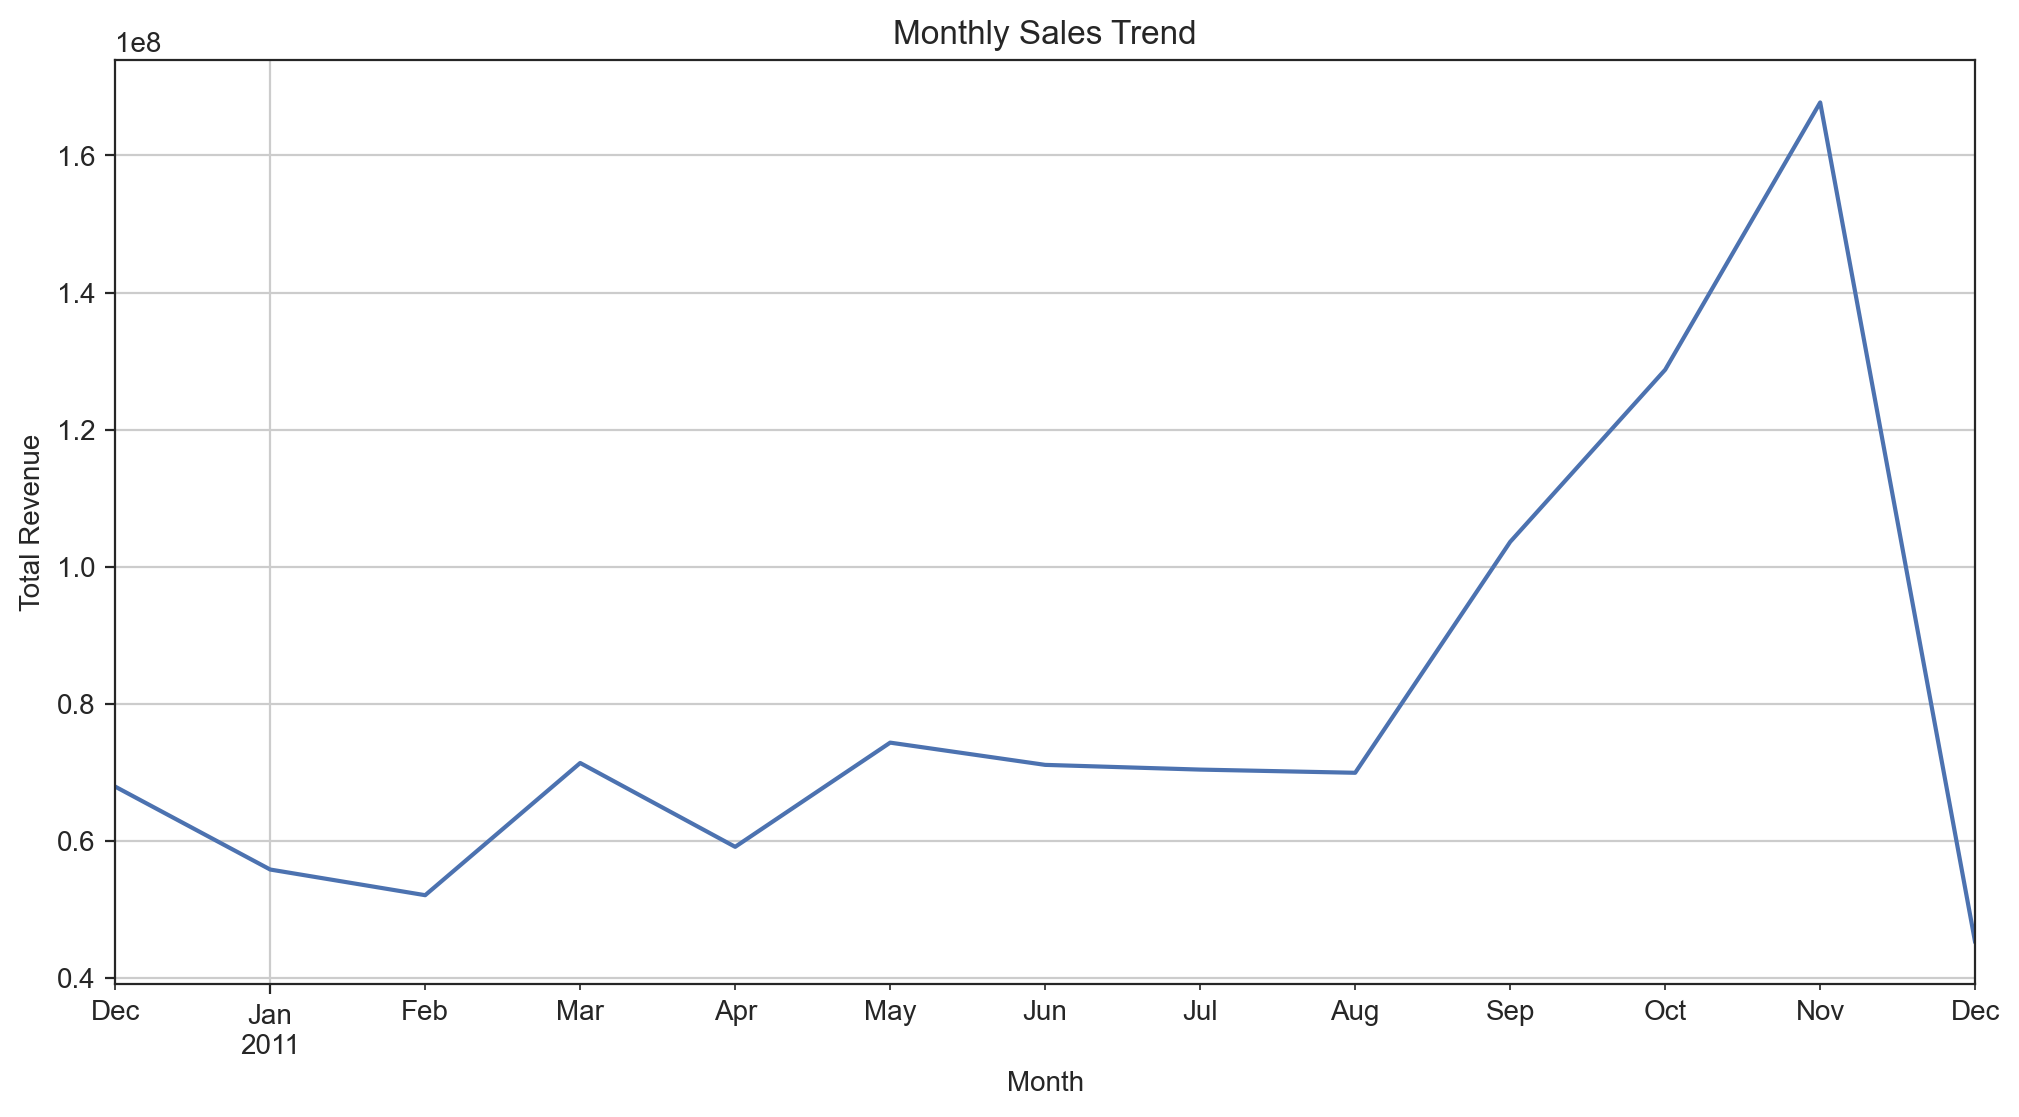

In [34]:
# Sales Trends Over Time
monthly_sales = ecom_data.groupby(ecom_data['InvoiceDate'].dt.to_period('M'))['TotalPrice'].sum()

plt.figure(figsize=(12,6))
monthly_sales.plot()
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.grid(True)
plt.show()

### Observation - Initial dip: Sales slightly declined from December to February, reaching a low point in February.¶¶
### Moderate Recovery: There was a modest increase in March and May, but the trend remained relatively flat from June to August.
### Strong Growth Phase: Sales began to climb sharply from September to November, peaking in November — the highest revenue month.
### Sharp Drop: A dramatic drop occurred in December, likely due to seasonal closure e.g., holiday break or end of the data collection period.

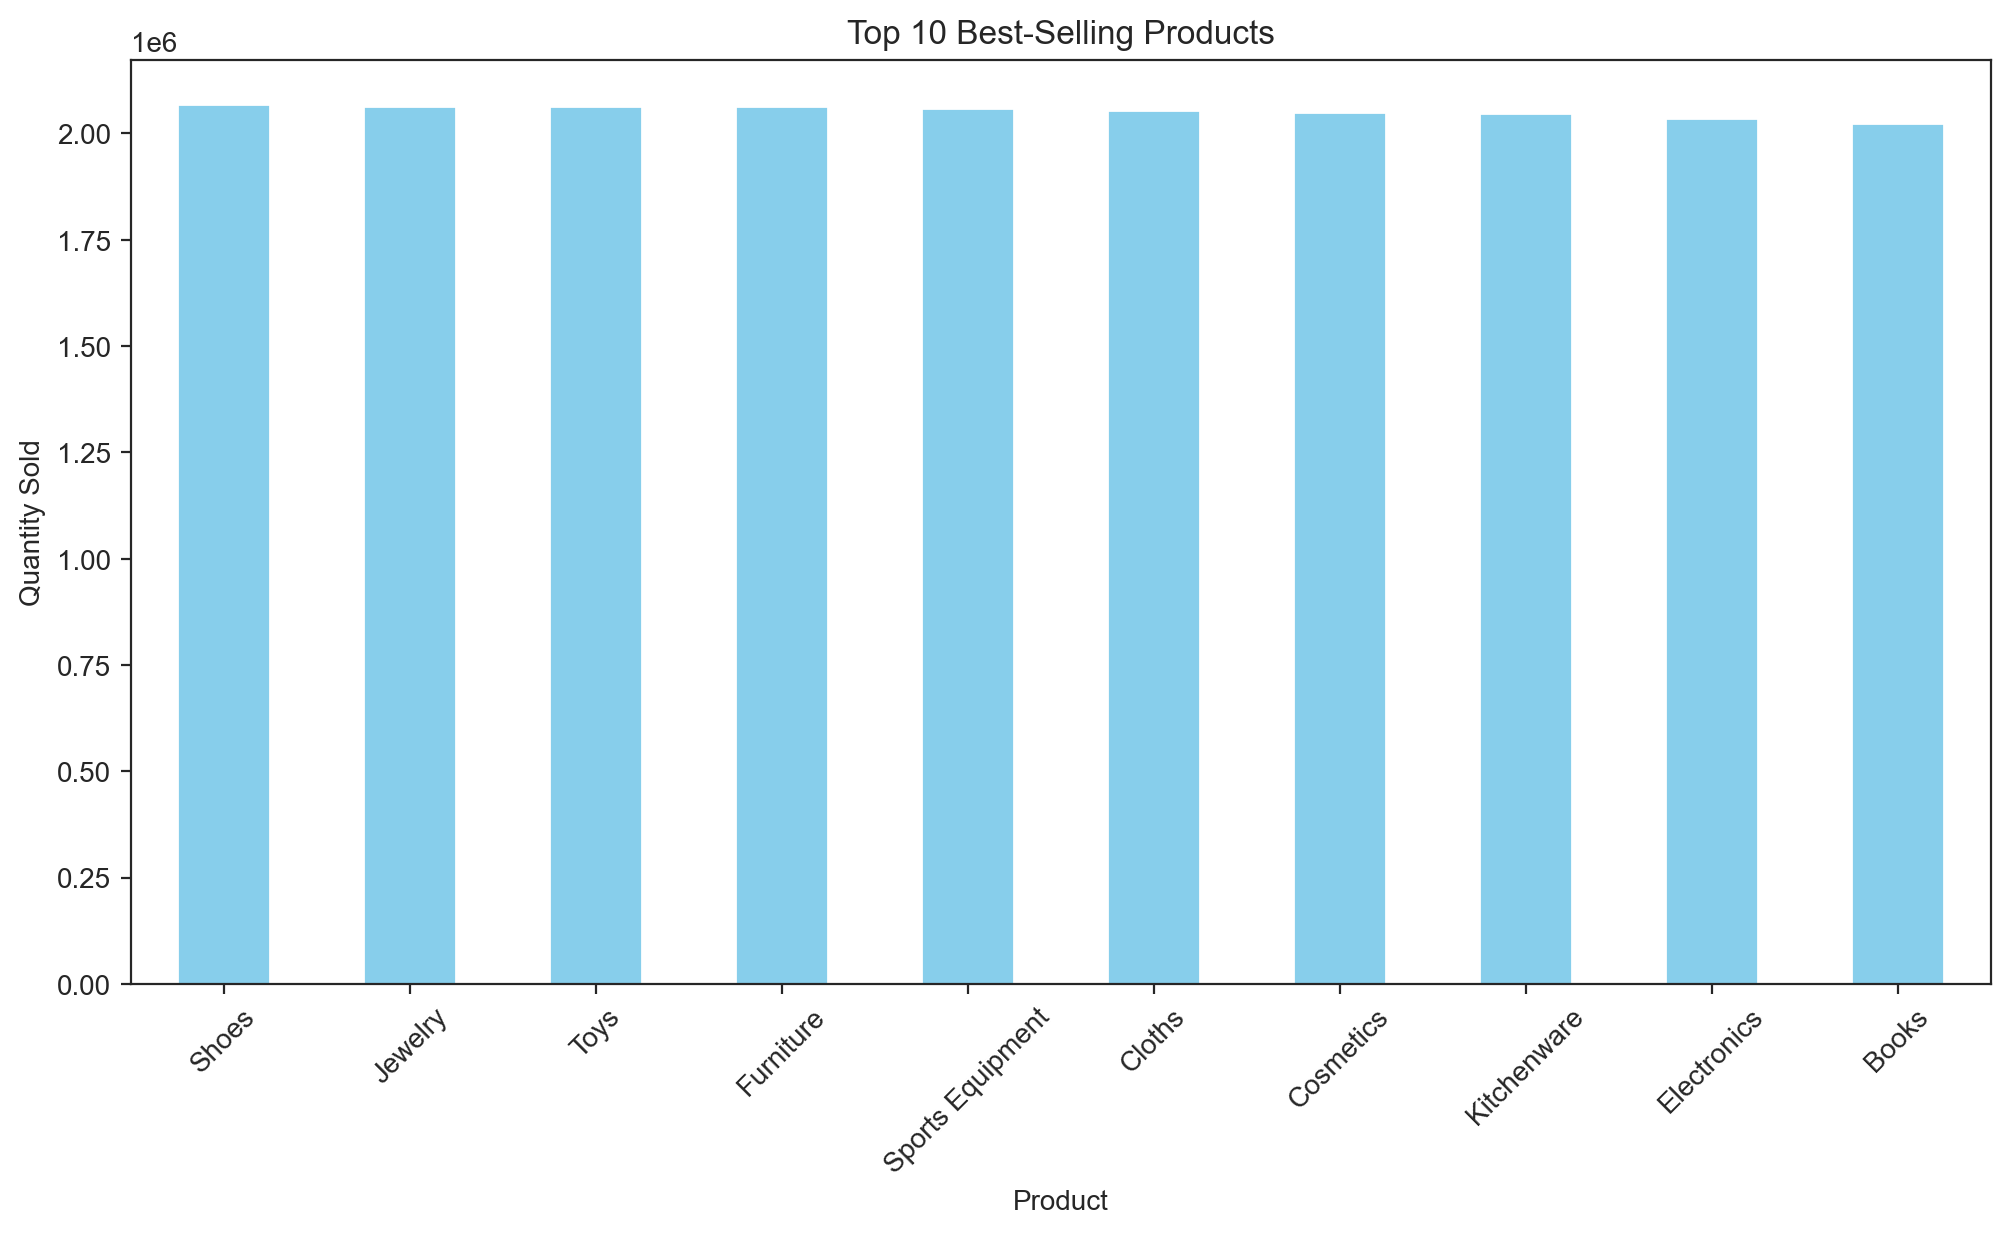

In [36]:
# Top Selling Products
# Total quantity sold per product
top_products = ecom_data.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

# Plot
top_products.plot(kind='bar', figsize=(12,6), color='skyblue')
plt.title('Top 10 Best-Selling Products')
plt.xlabel('Product')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=45)
plt.show()

### The bar chart above highlights the Top 10 Best-Selling Products based on the total quantity sold. The sales figures across these categories are nearly identical, with each product line approaching 2 million units sold. Shoes lead marginally, followed by Jewelry, Toys, and Furniture, among others.This uniformity suggests a well-diversified product portfolio with balanced consumer demand across different segments. Such even distribution of sales indicates effective inventory and marketing strategies, reducing over-dependence on any one product. Moreover, this can enhance business resilience and optimize overall performance throughout seasonal or market fluctuations.

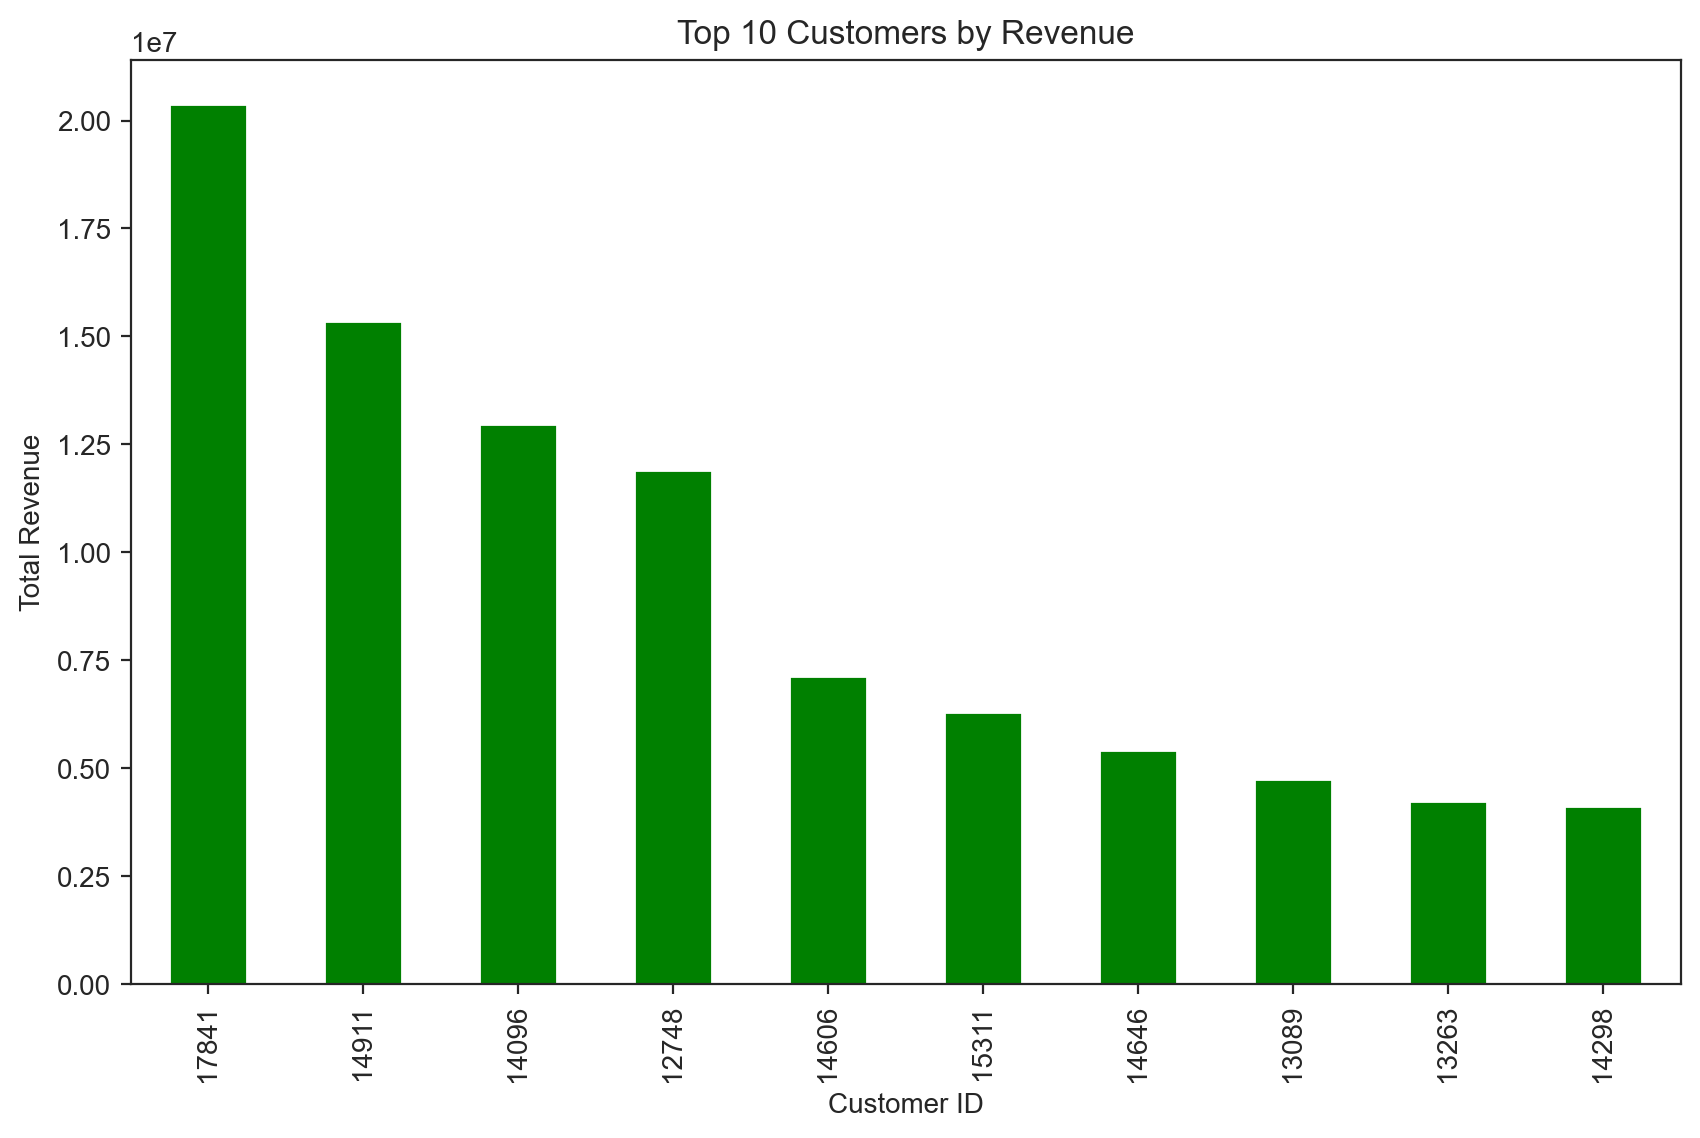

In [38]:
# Customer Purchase Behavior
# Total Revenue per Customer
customer_revenue = ecom_data.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False)

customer_revenue.head(10).plot(kind='bar', figsize=(10,6), color='green')
plt.title('Top 10 Customers by Revenue')
plt.xlabel('Customer ID')
plt.ylabel('Total Revenue')
plt.show()

### The bar chart visualizes the Top 10 Customers by Total Revenue, highlighting the most valuable clients based on their purchasing behavior.
### - The customer with ID 17841.0 generated the highest revenue, exceeding 20 million in total. This customer stands out significantly compared to the rest, suggesting a very strong transactional relationship.
### - Following this, Customers 14911.0 and 14096.0 also contribute notably, each bringing in revenues between 13 and 15 million respectively.
### - There is a gradual decline in revenue as we move from left to right across the chart. The 10th highest customer (Customer ID 14298.0) still contributed over 5 million, but this is less than one-third of the top customer's contribution.¶
### - Overall, this pattern indicates a concentration of revenue among a few key clients, with a steep revenue drop beyond the top 5.
### Business Insight - The data suggests that a small number of customers account for a disproportionate share of total revenue, with the top 3 customers alone generating a significant chunk. This emphasizes the importance of customer relationship management and retention strategies for these high-value clients. At the same time, there is an opportunity to nurture mid-tier customers (like those ranked 6–10) to increase their spend and move them higher up the revenue ladder.

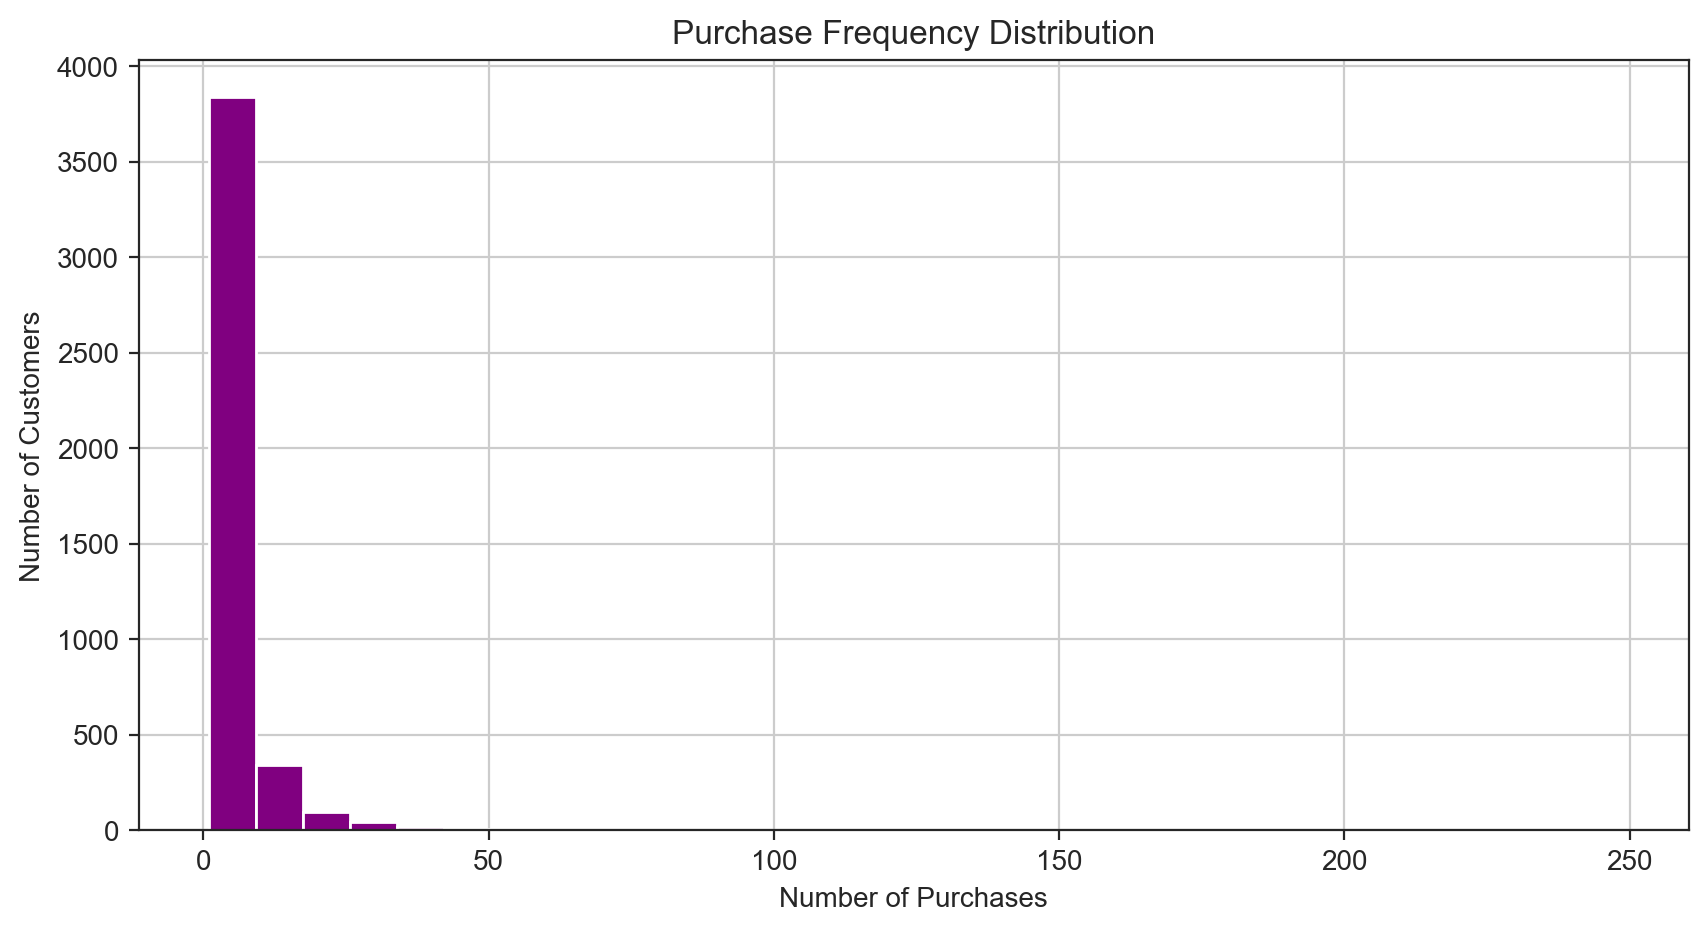

In [40]:
# Frequency of Purchase
customer_frequency = ecom_data.groupby('CustomerID')['InvoiceDate'].nunique()

customer_frequency.hist(bins=30, figsize=(10,5), color='purple')
plt.title('Purchase Frequency Distribution')
plt.xlabel('Number of Purchases')
plt.ylabel('Number of Customers')
plt.show()

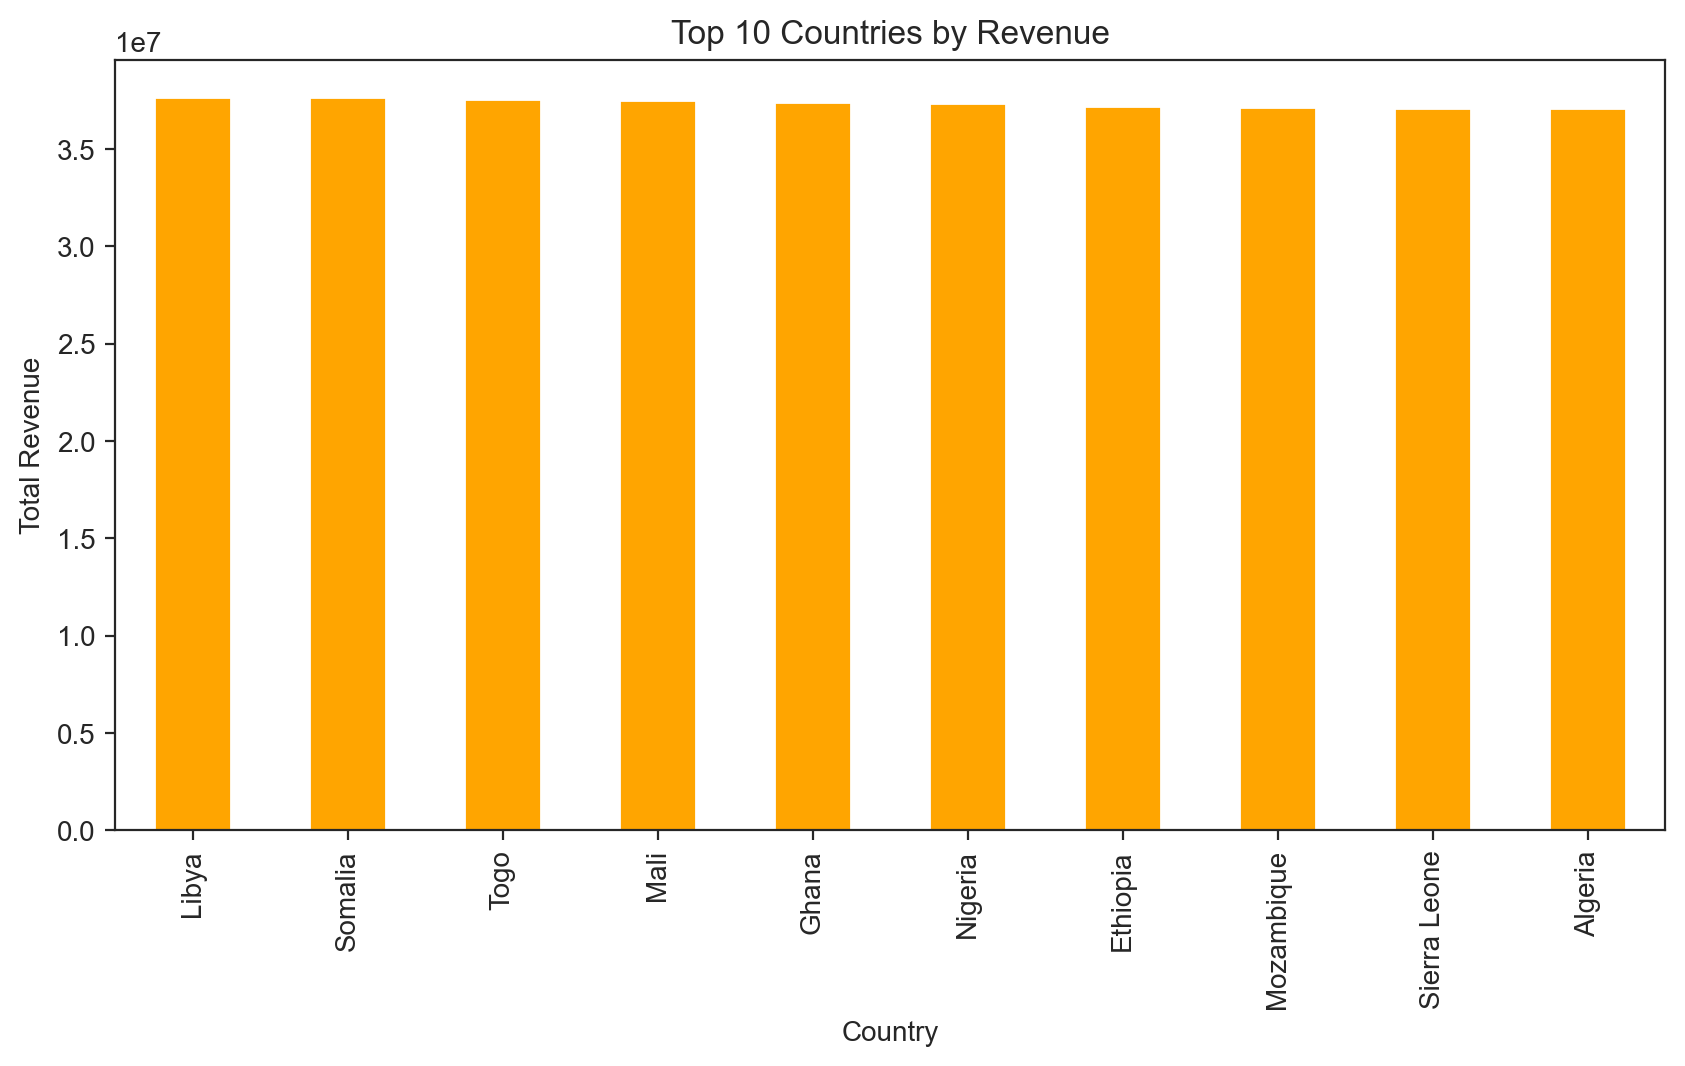

In [41]:
# Sales by Country
country_sales = ecom_data.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

country_sales.plot(kind='bar', figsize=(10,5), color='orange')
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Total Revenue')
plt.show()

### The bar chart visualizes the Top 10 Countries by Total Revenue, highlighting the countrue with the highest revenue based on their purchases. Libya at the top means customers from Libya made the most purchases or bought higher-priced items, followed by Somalia, then Togo, Mali, Ghana, down to Algeria. Countries at the top might be high-value markets for the business, this can inform targeted marketing strategies, e.g., offer premium services in Libya or Somalia. Interesting that many of the top countries are in Africa — this could reflect a niche or regional market the business serves.

# Calculate Recency, Frequency, Monetary and Customer Tenure

In [45]:
# Reference date for Recency (last purchase + buffer)
reference_date = ecom_data['InvoiceDate'].max() + pd.Timedelta(days=7)

In [46]:
# RFM calculation
rfm = ecom_data.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                    # Frequency
    'TotalPrice': 'sum'                                        # Monetary
})

In [51]:
# Rename columns
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [53]:
# Preview
print(rfm.head())

            Recency  Frequency   Monetary
CustomerID                               
12346           332          2    5342.40
12347             8          7  431501.00
12348            81          4   82378.47
12349            25          1  176075.12
12350           316          1   48173.37


In [54]:
# Group by CustomerID to get first and last purchase dates
cus_tenure = ecom_data.groupby('CustomerID').agg({
    'InvoiceDate': ['min', 'max']
})

# Rename columns
cus_tenure.columns = ['FirstPurchaseDate', 'LastPurchaseDate']

# Calculate tenure in days
cus_tenure['TenureDays'] = (cus_tenure['LastPurchaseDate'] - cus_tenure['FirstPurchaseDate']).dt.days

In [69]:
# Merge RFM and Tenure into a single DataFrame
cus_feat = rfm.merge(cus_tenure[['TenureDays']], left_index=True, right_index=True)

In [72]:
# Reset index 'CustomerID' as a column
cus_feat = cus_feat.reset_index()

In [73]:
cus_feat.head(2)

,CustomerID,Recency,Frequency,Monetary,TenureDays
0,12346,332,2,5342.4,0
1,12347,8,7,431501.0,365


In [85]:
# Save to CSV
cus_feat.to_csv("customer_features.csv", index=False)

# Cohort Segmentation

In [88]:
# Create CohortMonth (customer's first purchase month)
ecom_data['CohortMonth'] = ecom_data.groupby('CustomerID')['InvoiceDate'].transform('min').dt.to_period('M')

In [90]:
# Convert Period[M] to Timestamp
invoice_month = ecom_data['InvoiceMonth'].dt.to_timestamp()
cohort_month = ecom_data['CohortMonth'].dt.to_timestamp()

In [92]:
# Calculate difference in months
years_diff = invoice_month.dt.year - cohort_month.dt.year
months_diff = invoice_month.dt.month - cohort_month.dt.month

In [94]:
# Final CohortIndex
ecom_data['CohortIndex'] = years_diff * 12 + months_diff + 1

In [96]:
# Count unique customers in each CohortMonth + CohortIndex
cohort_data = ecom_data.groupby(['CohortMonth', 'CohortIndex']) \
                .agg(n_customers=('CustomerID', 'nunique')) \
                .reset_index()

In [98]:
# Get the size of each cohort (number of customers in month 1)
cohort_sizes = cohort_data[cohort_data['CohortIndex'] == 1][['CohortMonth', 'n_customers']]
cohort_sizes.rename(columns={'n_customers': 'cohort_size'}, inplace=True)

In [100]:
# Merge to calculate retention rate
cohort_data = cohort_data.merge(cohort_sizes, on='CohortMonth')
cohort_data['RetentionRate'] = cohort_data['n_customers'] / cohort_data['cohort_size']

In [102]:
# Pivot to create retention matrix
cohort_retention = cohort_data.pivot(index='CohortMonth',
                                     columns='CohortIndex',
                                     values='RetentionRate')

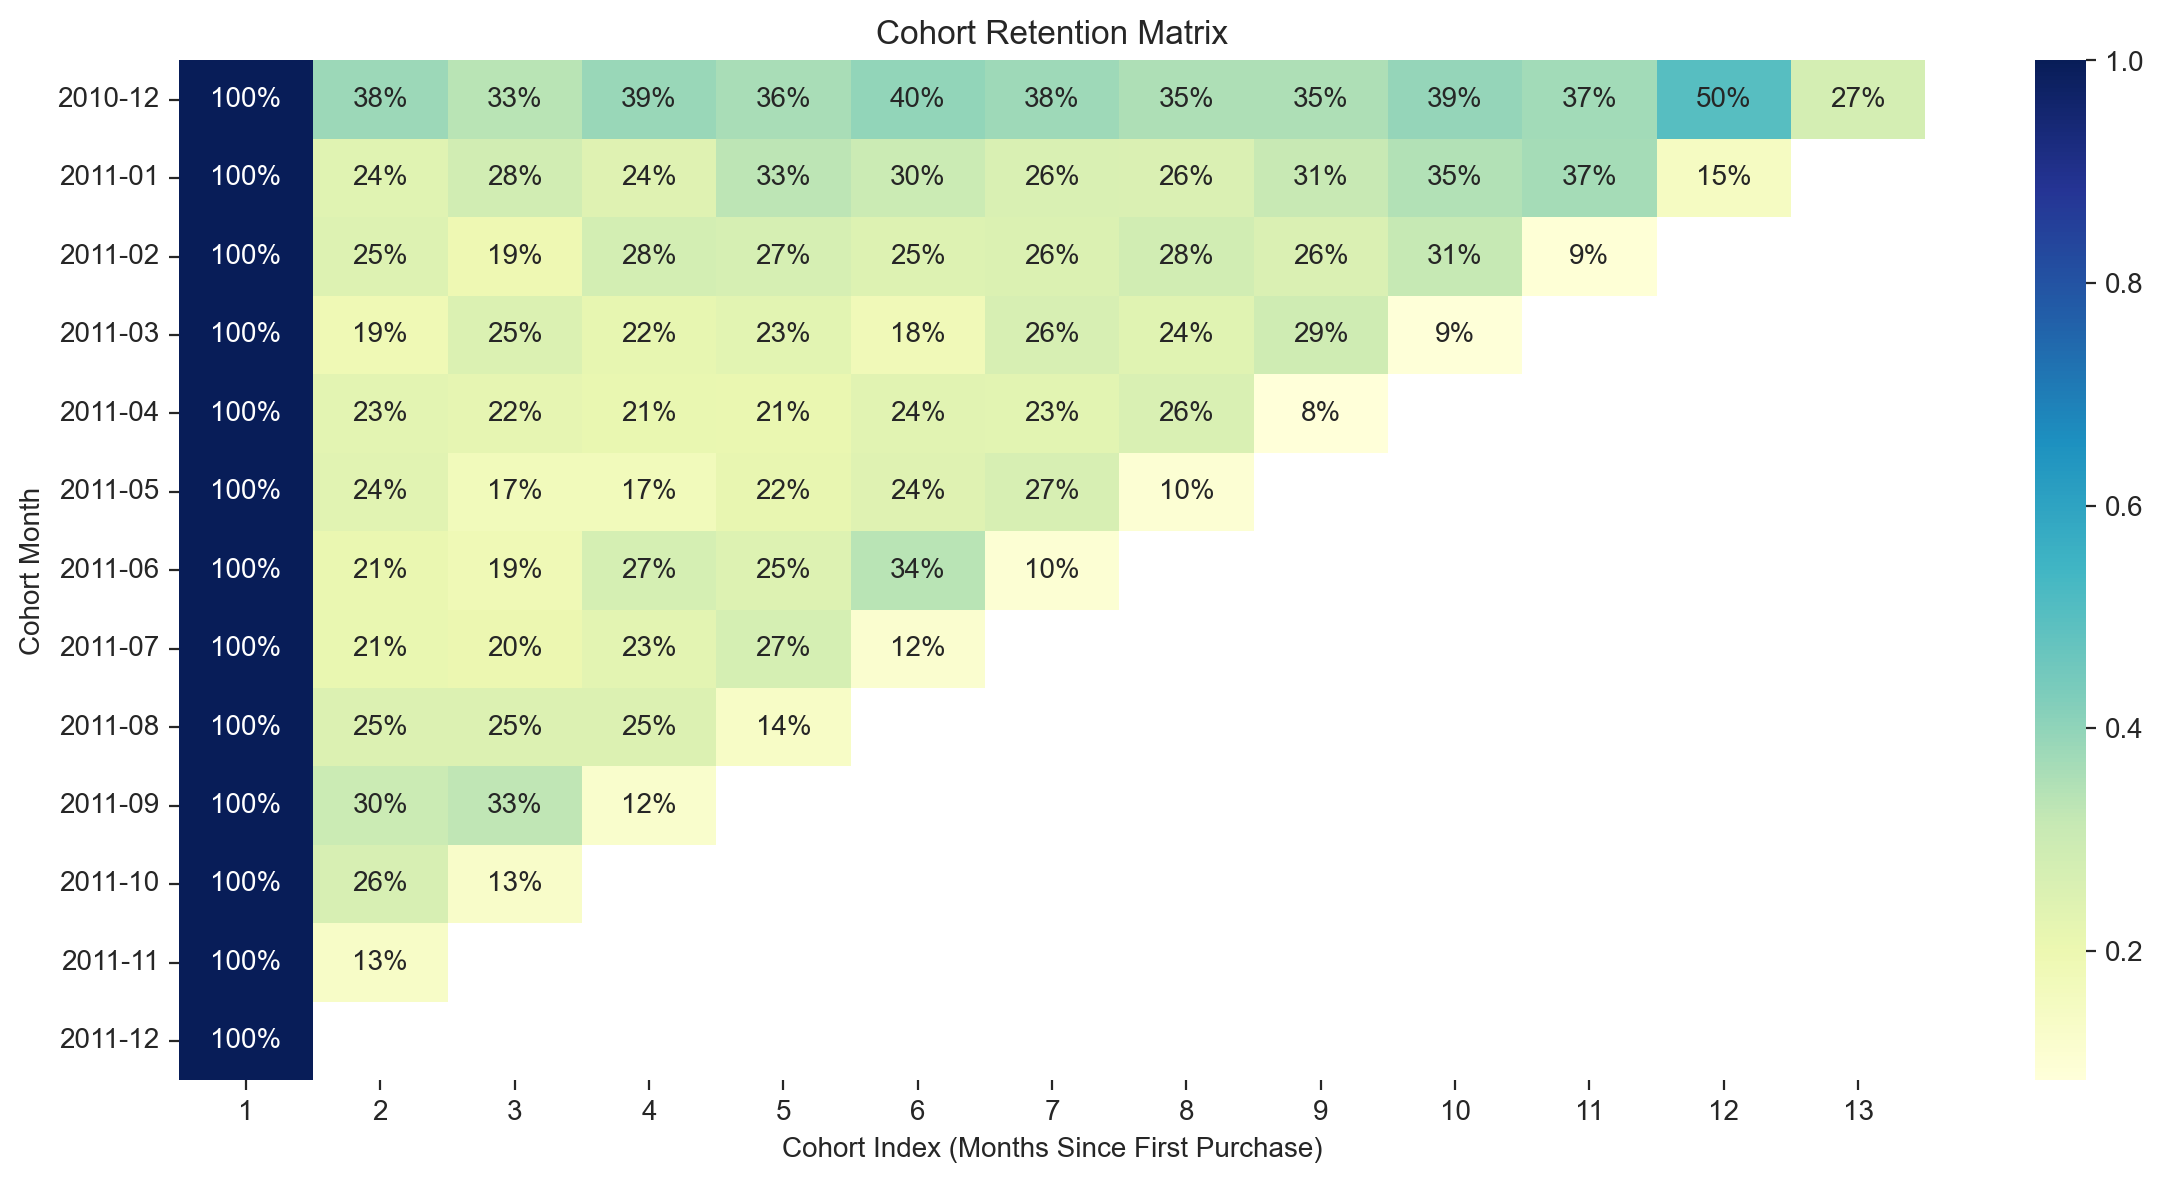

In [104]:
# Visualize with heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(cohort_retention, annot=True, fmt=".0%", cmap="YlGnBu")
plt.title('Cohort Retention Matrix')
plt.xlabel('Cohort Index (Months Since First Purchase)')
plt.ylabel('Cohort Month')
plt.tight_layout()
plt.show()

### The cohort retention matrix shows the proportion of customers remaining active over time. The matrix showed a significant decline in retention from Month 1 to Month 2 across all cohorts. This sharp drop suggests that many customers only made one purchase and did not return, which may highlight issues such as lack of effective post-purchase engagement, limited product variety or perceived value, potential pricing or service-related concerns, weak onboarding or communication strategy. Despite dropping from 100% in Month 1 to 38% in Month 2, the December 2010 cohort maintained a remarkably consistent retention over time, reaching 50% in Month 12. This could be attributed to seasonal shopping habits such as holiday purchases in December, well-executed promotional campaigns or discounts and elevated customer experience during the festive season. The matrix reflects a general downward trend in retention as the months progress — with most cohorts struggling to maintain engagement after the first few months. It is also observed that every cohort tends to underperformed in December 2011.

# Retention Curves

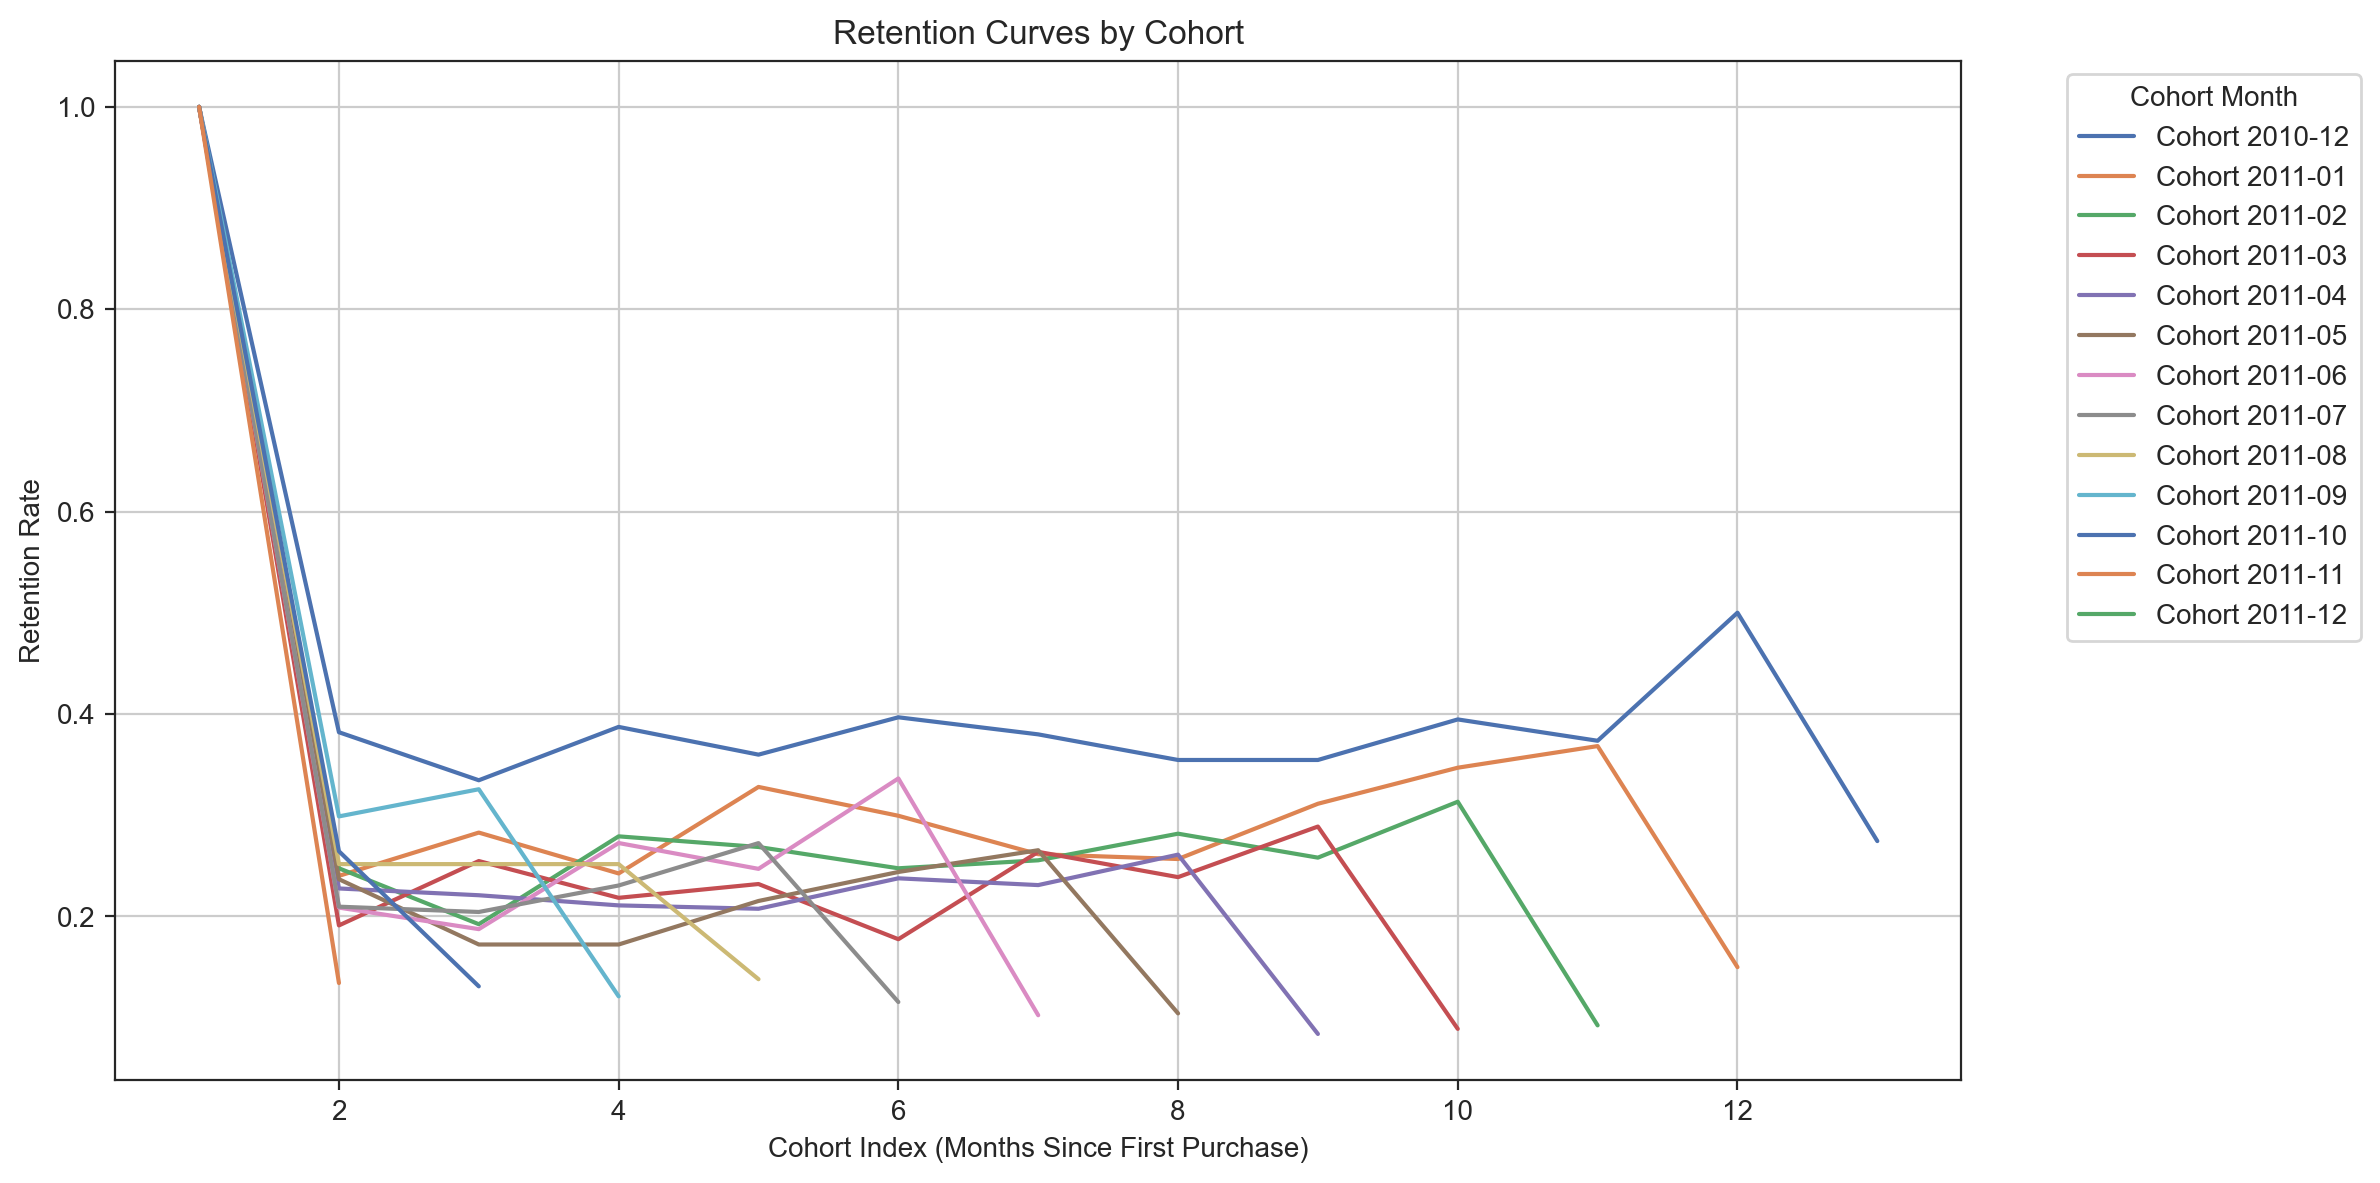

In [108]:
# Plot retention curves for each cohort (using the cohort_retention matrix)
plt.figure(figsize=(12, 6))

# Loop over each cohort (CohortMonth) and plot the retention curve
for cohort in cohort_retention.index:  # Iterate over each cohort
    plt.plot(cohort_retention.columns, cohort_retention.loc[cohort], label=f'Cohort {cohort.strftime("%Y-%m")}')

plt.title("Retention Curves by Cohort")
plt.xlabel("Cohort Index (Months Since First Purchase)")
plt.ylabel("Retention Rate")
plt.legend(title='Cohort Month', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

In [110]:
cohort_data = ecom_data.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'].nunique().reset_index()
cohort_counts = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='CustomerID')

print(cohort_counts.head())

CohortIndex     1      2      3      4      5      6      7      8      9   \
CohortMonth                                                                  
2010-12      948.0  362.0  317.0  367.0  341.0  376.0  360.0  336.0  336.0   
2011-01      421.0  101.0  119.0  102.0  138.0  126.0  110.0  108.0  131.0   
2011-02      380.0   94.0   73.0  106.0  102.0   94.0   97.0  107.0   98.0   
2011-03      440.0   84.0  112.0   96.0  102.0   78.0  116.0  105.0  127.0   
2011-04      299.0   68.0   66.0   63.0   62.0   71.0   69.0   78.0   25.0   

CohortIndex     10     11     12     13  
CohortMonth                              
2010-12      374.0  354.0  474.0  260.0  
2011-01      146.0  155.0   63.0    NaN  
2011-02      119.0   35.0    NaN    NaN  
2011-03       39.0    NaN    NaN    NaN  
2011-04        NaN    NaN    NaN    NaN  


In [112]:
cohort_data.rename(columns = {"CustomerID" : "Number of customers"}, inplace = True)

In [114]:
cohort_data

,CohortMonth,CohortIndex,Number of customers
0,2010-12,1,948
1,2010-12,2,362
2,2010-12,3,317
3,2010-12,4,367
4,2010-12,5,341
...,...,...,...
86,2011-10,2,93
87,2011-10,3,46
88,2011-11,1,321
89,2011-11,2,43


In [116]:
cohort_table = cohort_data.pivot(index = 'CohortMonth', columns =  ['CohortIndex'], values = "Number of customers")

In [118]:
cohort_table

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2010-12,948.0,362.0,317.0,367.0,341.0,376.0,360.0,336.0,336.0,374.0,354.0,474.0,260.0
2011-01,421.0,101.0,119.0,102.0,138.0,126.0,110.0,108.0,131.0,146.0,155.0,63.0,NaN
2011-02,380.0,94.0,73.0,106.0,102.0,94.0,97.0,107.0,98.0,119.0,35.0,NaN,NaN
2011-03,440.0,84.0,112.0,96.0,102.0,78.0,116.0,105.0,127.0,39.0,NaN,NaN,NaN
2011-04,299.0,68.0,66.0,63.0,62.0,71.0,69.0,78.0,25.0,NaN,NaN,NaN,NaN
2011-05,279.0,66.0,48.0,48.0,60.0,68.0,74.0,29.0,NaN,NaN,NaN,NaN,NaN
2011-06,235.0,49.0,44.0,64.0,58.0,79.0,24.0,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,191.0,40.0,39.0,44.0,52.0,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,167.0,42.0,42.0,42.0,23.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


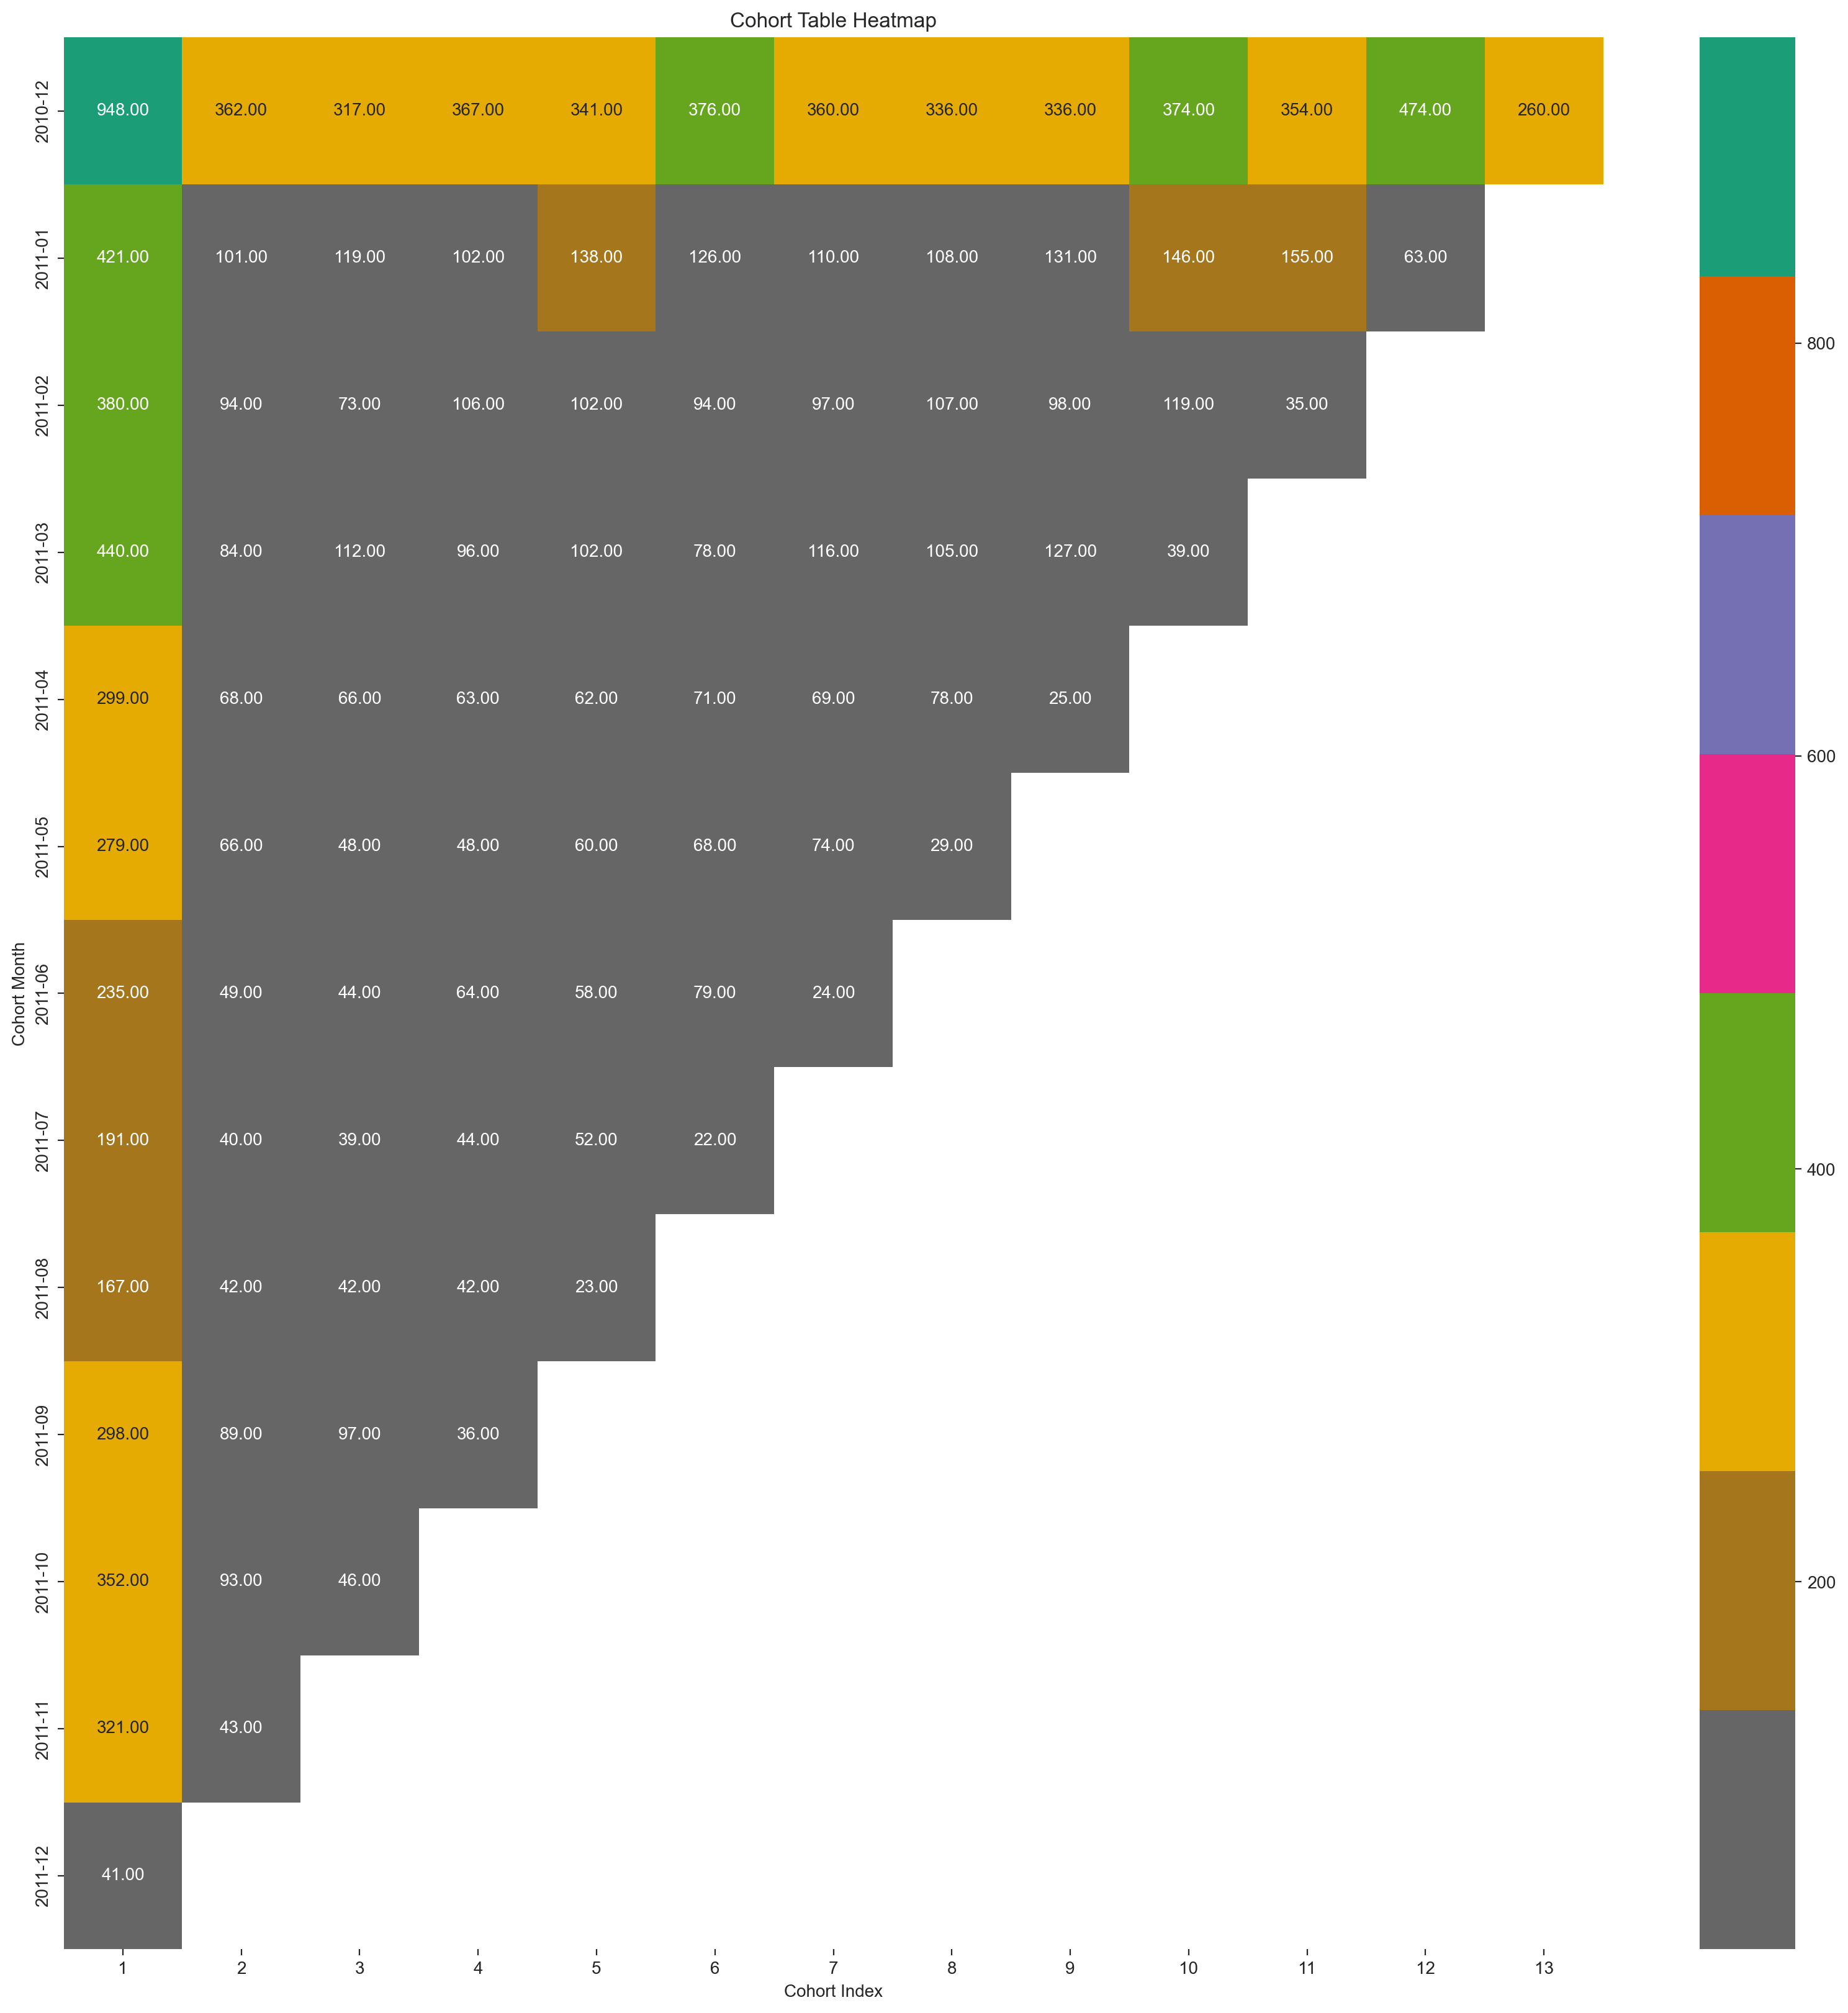

In [120]:
plt.figure(figsize=(20, 20))
sns.heatmap(cohort_table, annot=True, cmap="Dark2_r", fmt = ".2f")
plt.title('Cohort Table Heatmap')
plt.ylabel('Cohort Month')
plt.xlabel('Cohort Index')
plt.show()

# Churn Timing Analysis

In [123]:
# Define churn threshold (customers are considered churned if retention falls below 30% in a month)
churn_threshold = 0.3

In [125]:
# Calculate churn month for each cohort
churn_timing = []

for cohort in cohort_retention.index:
    # Get the retention rates for the cohort
    retention_values = cohort_retention.loc[cohort].values
    
    # Find the first month where retention is below the threshold (churn month)
    churn_month = np.argmax(retention_values < churn_threshold) + 1  # Adding 1 to match CohortIndex
    if retention_values[0] >= churn_threshold:  # Only consider customers who don't churn immediately
        churn_timing.append(churn_month)

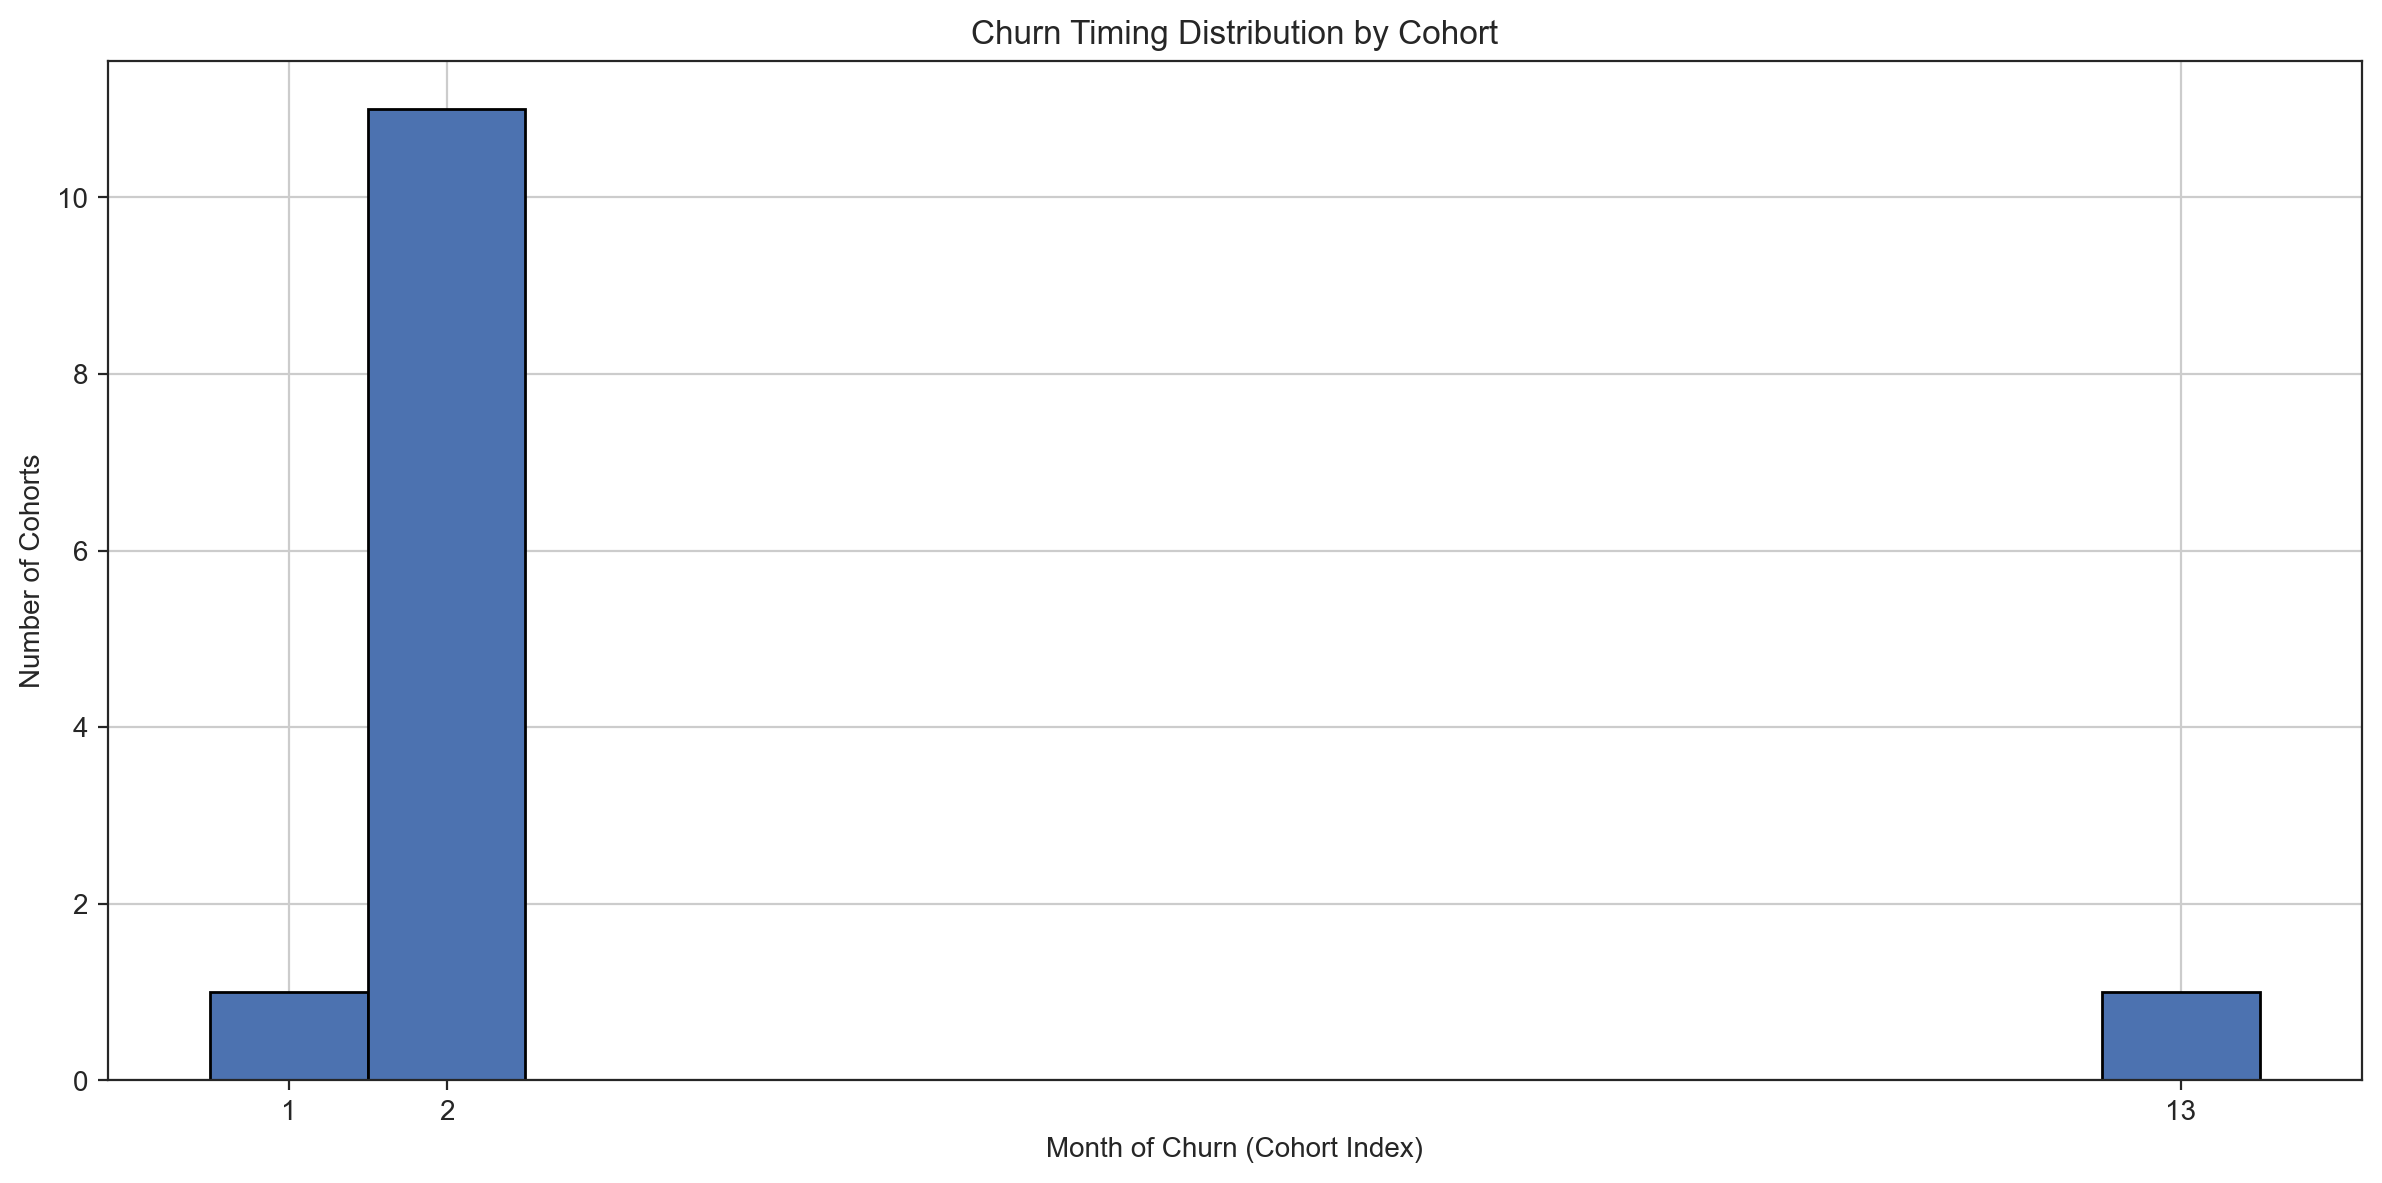

In [127]:
# Churn timing analysis: Count the frequency of churn in each month across cohorts
churn_counts = pd.Series(churn_timing).dropna().astype(int)

# Plot churn timing distribution (when customers are most likely to churn)
plt.clf()
plt.close('all')  # Clear any previous figures that might cause ghost/empty plots

plt.figure(figsize=(12, 6))
plt.hist(churn_counts, bins=range(1, churn_counts.max() + 2), edgecolor="black", align="left")
plt.title("Churn Timing Distribution by Cohort")
plt.xlabel("Month of Churn (Cohort Index)")
plt.ylabel("Number of Cohorts")
plt.xticks(sorted(churn_counts.unique()))  # Modified line: dynamic ticks based on actual values
plt.grid(True)
plt.tight_layout()
plt.show()

### Observation - The histogram of churn timing distribution by cohort showed that majority of customers tend to churn in Month 2. This shows that the risk of losing customers is highest Month 2.

# Defining Churn Logic

In [131]:
# Define churn logic based on 3 months of inactivity
# Get last purchase date per customer
last_purchase = ecom_data.groupby('CustomerID')['InvoiceDate'].max()

cutoff_date = ecom_data['InvoiceDate'].max() - pd.DateOffset(months=3)
churn_flag = last_purchase < cutoff_date

# Combine into customer profile
customer_churn_df = pd.DataFrame({
    'LastPurchase': last_purchase,
    'IsChurned': churn_flag
})

print(customer_churn_df.head())

                  LastPurchase  IsChurned
CustomerID                               
12346      2011-01-18 10:17:00       True
12347      2011-12-07 15:52:00      False
12348      2011-09-25 13:13:00      False
12349      2011-11-21 09:51:00      False
12350      2011-02-02 16:01:00       True


In [133]:
print(customer_churn_df['IsChurned'].value_counts())

IsChurned
False    2922
True     1450
Name: count, dtype: int64


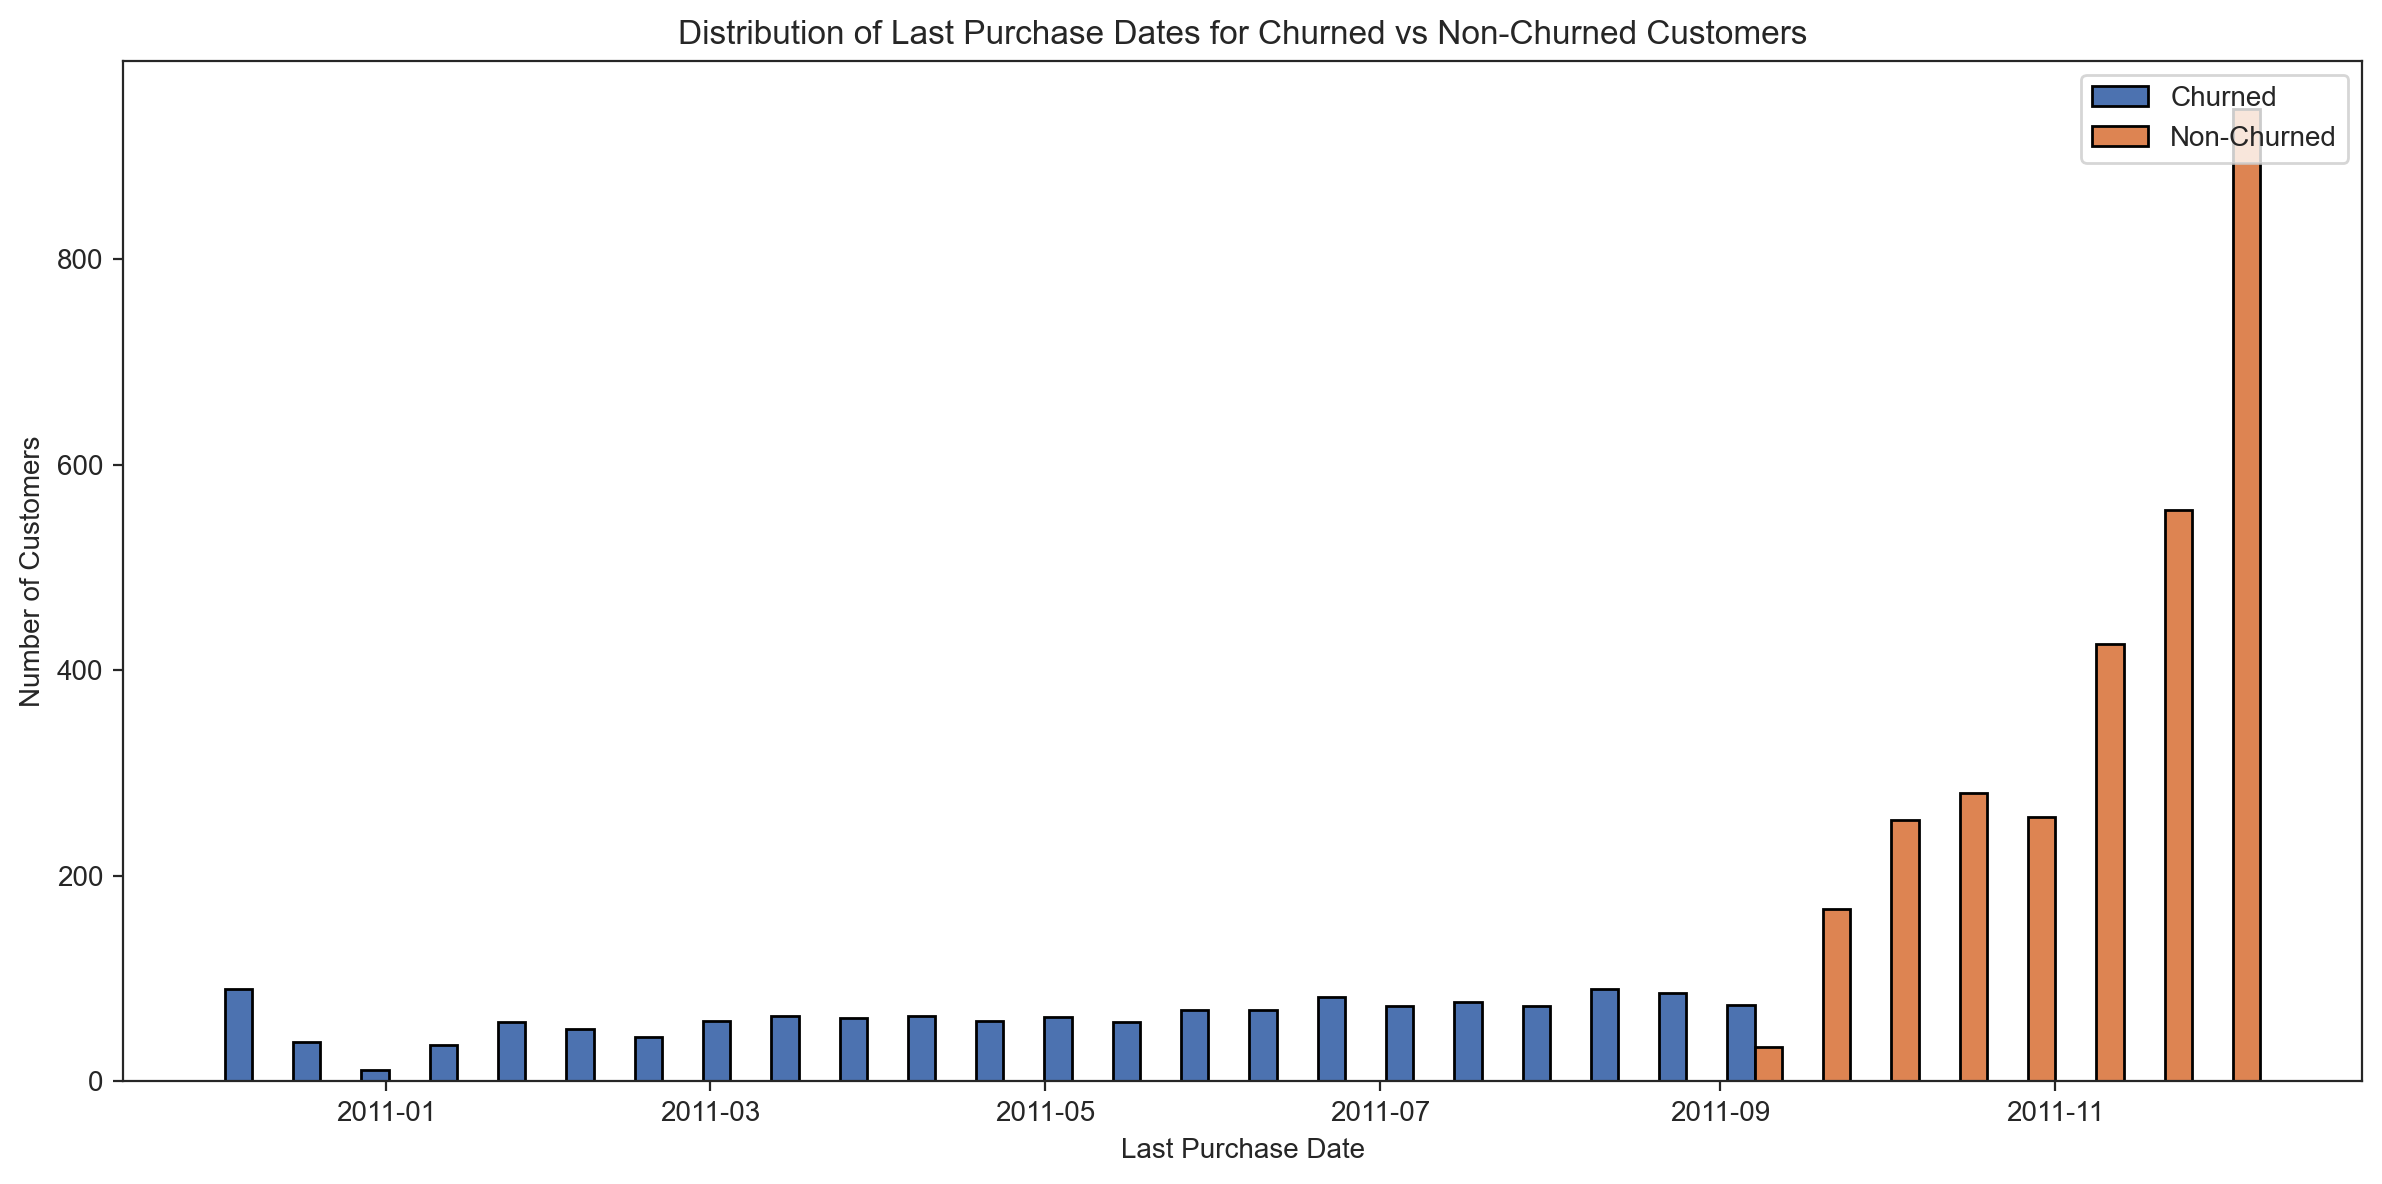

In [135]:
# Plot churn vs non-churned customers for diagnostic purposes
plt.figure(figsize=(12, 6))
churned_customers = customer_churn_df[customer_churn_df['IsChurned'] == True]
non_churned_customers = customer_churn_df[customer_churn_df['IsChurned'] == False]

# Plot churned and non-churned distributions
plt.hist([churned_customers['LastPurchase'], non_churned_customers['LastPurchase']], bins=30, edgecolor='black', label=['Churned', 'Non-Churned'])
plt.legend(loc='upper right')
plt.title('Distribution of Last Purchase Dates for Churned vs Non-Churned Customers')
plt.xlabel('Last Purchase Date')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

# Explore Reasons For Churn

In [138]:
# Define churned and non-churned customers' IDs
churned_customers_ids = customer_churn_df[customer_churn_df['IsChurned'] == True].index
non_churned_customers_ids = customer_churn_df[customer_churn_df['IsChurned'] == False].index

In [140]:
# Filter ecom_data to separate churned and non-churned customers
churned_customers = ecom_data[ecom_data['CustomerID'].isin(churned_customers_ids)]
non_churned_customers = ecom_data[~ecom_data['CustomerID'].isin(churned_customers_ids)]

In [142]:
# Analyze the distribution of product categories (Description) between churned and non-churned customers
churned_categories = churned_customers['Description'].value_counts()
non_churned_categories = non_churned_customers['Description'].value_counts()

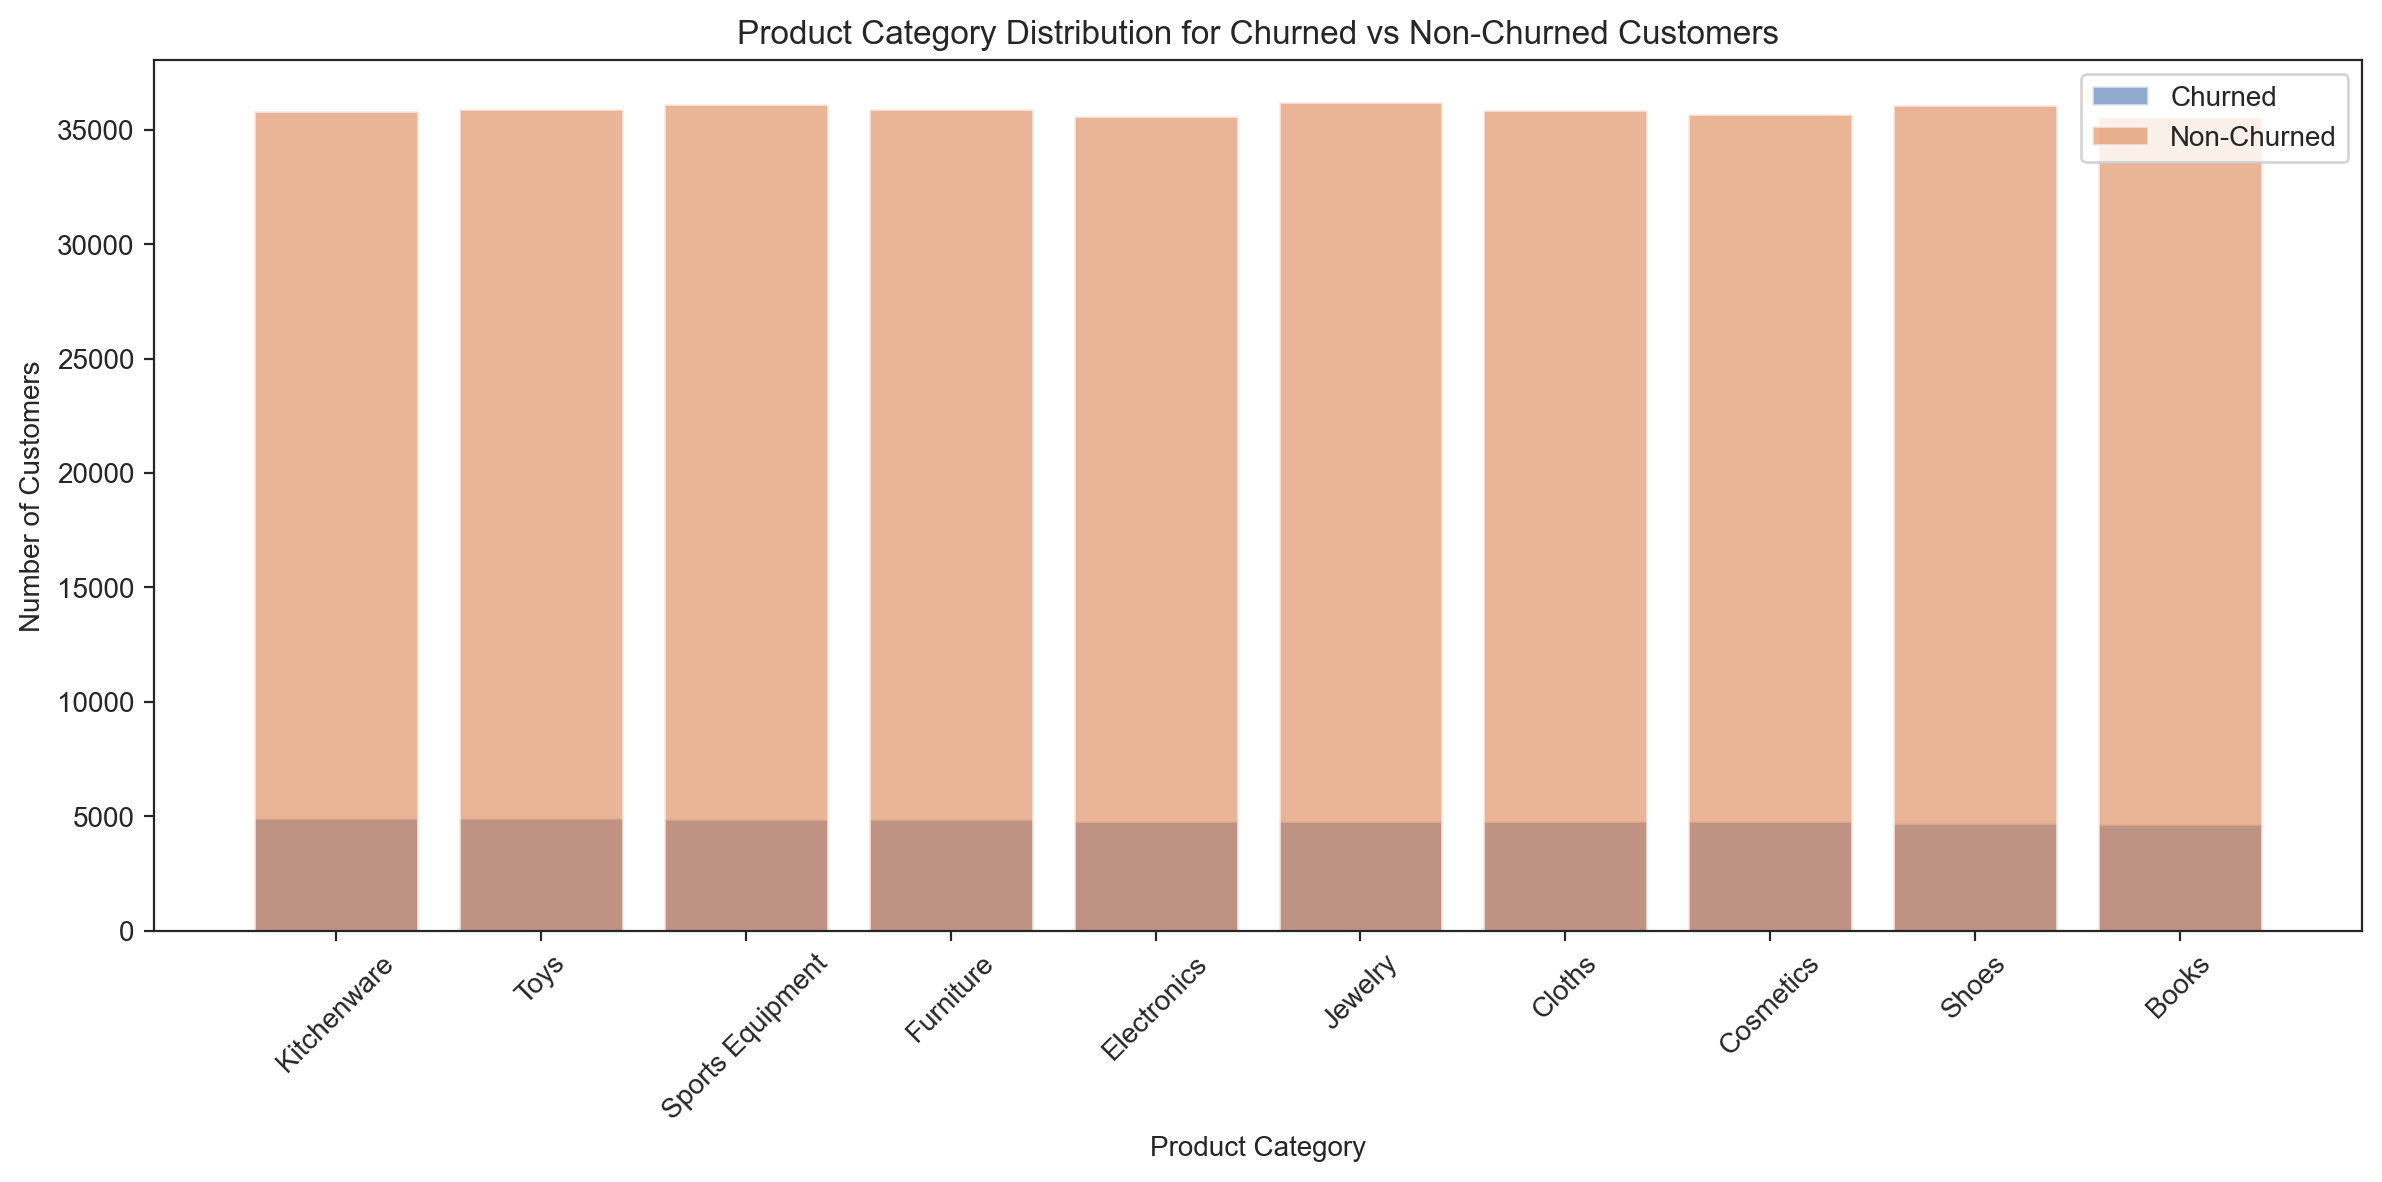

In [144]:
# Visualize the churned vs non-churned product category distribution
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.bar(churned_categories.index, churned_categories.values, alpha=0.6, label='Churned')
plt.bar(non_churned_categories.index, non_churned_categories.values, alpha=0.6, label='Non-Churned')
plt.title("Product Category Distribution for Churned vs Non-Churned Customers")
plt.xlabel("Product Category")
plt.ylabel("Number of Customers")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

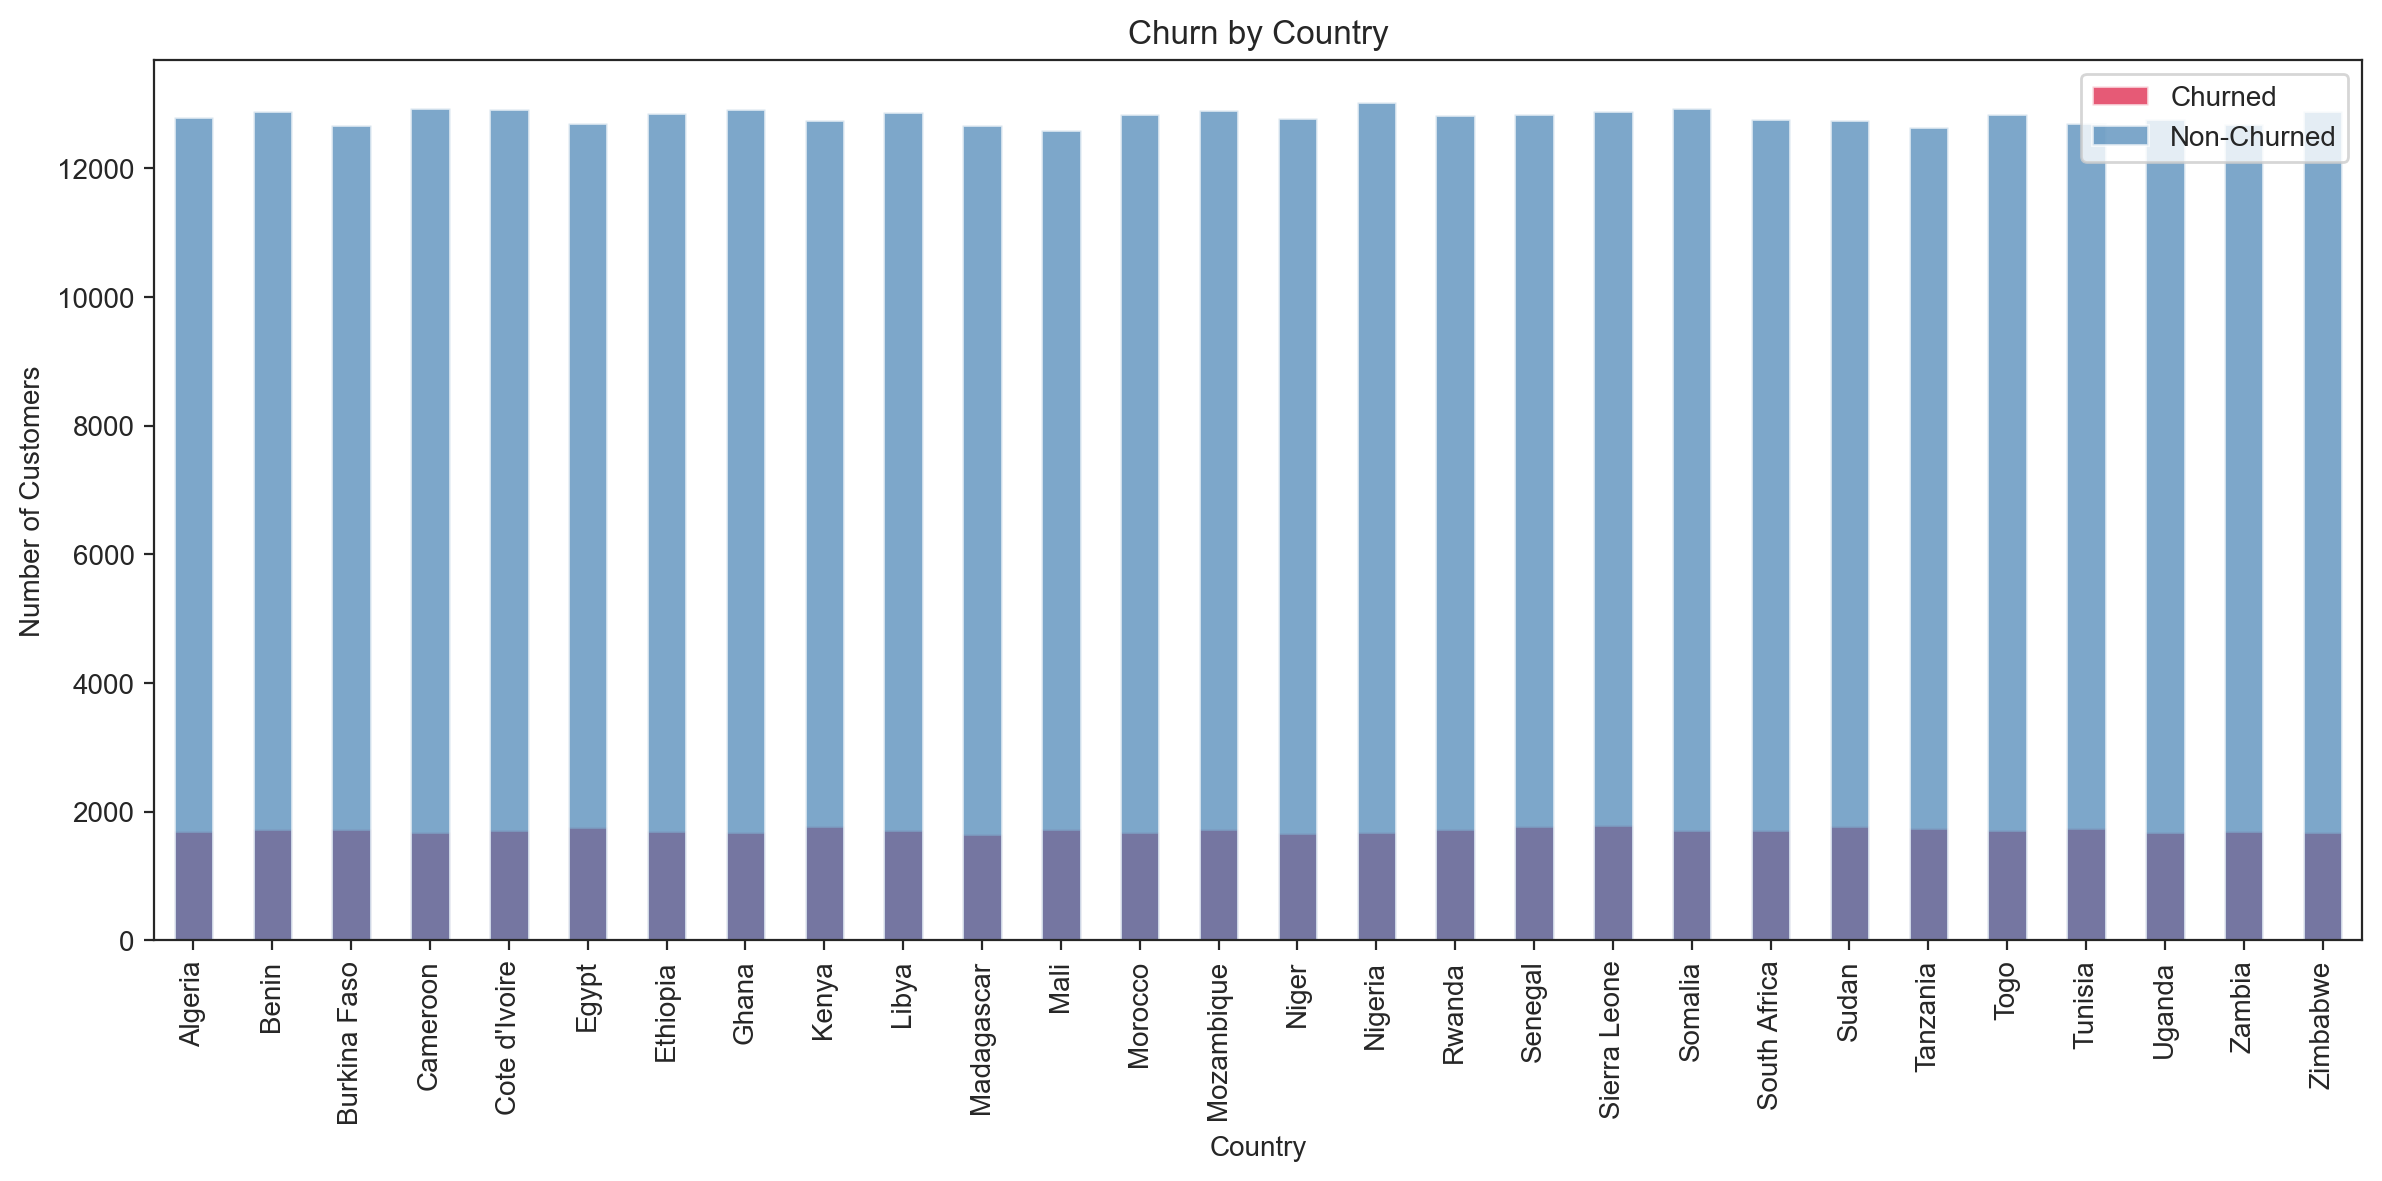

In [146]:
# Identify the Countries in which customer are more likely to churn.
churned_demographics = churned_customers.groupby('Country')['CustomerID'].count()
non_churned_demographics = non_churned_customers.groupby('Country')['CustomerID'].count()

# Align the index to avoid mismatch between plots
combined_index = churned_demographics.index.union(non_churned_demographics.index)
churned_demographics = churned_demographics.reindex(combined_index, fill_value=0)
non_churned_demographics = non_churned_demographics.reindex(combined_index, fill_value=0)

# Plot churn by country with distinct colors
plt.figure(figsize=(12, 6))
churned_demographics.plot(kind='bar', color='crimson', alpha=0.7, label='Churned')
non_churned_demographics.plot(kind='bar', color='steelblue', alpha=0.7, label='Non-Churned')

plt.title('Churn by Country')
plt.xlabel('Country')
plt.ylabel('Number of Customers')
plt.legend()
plt.tight_layout()
plt.show()

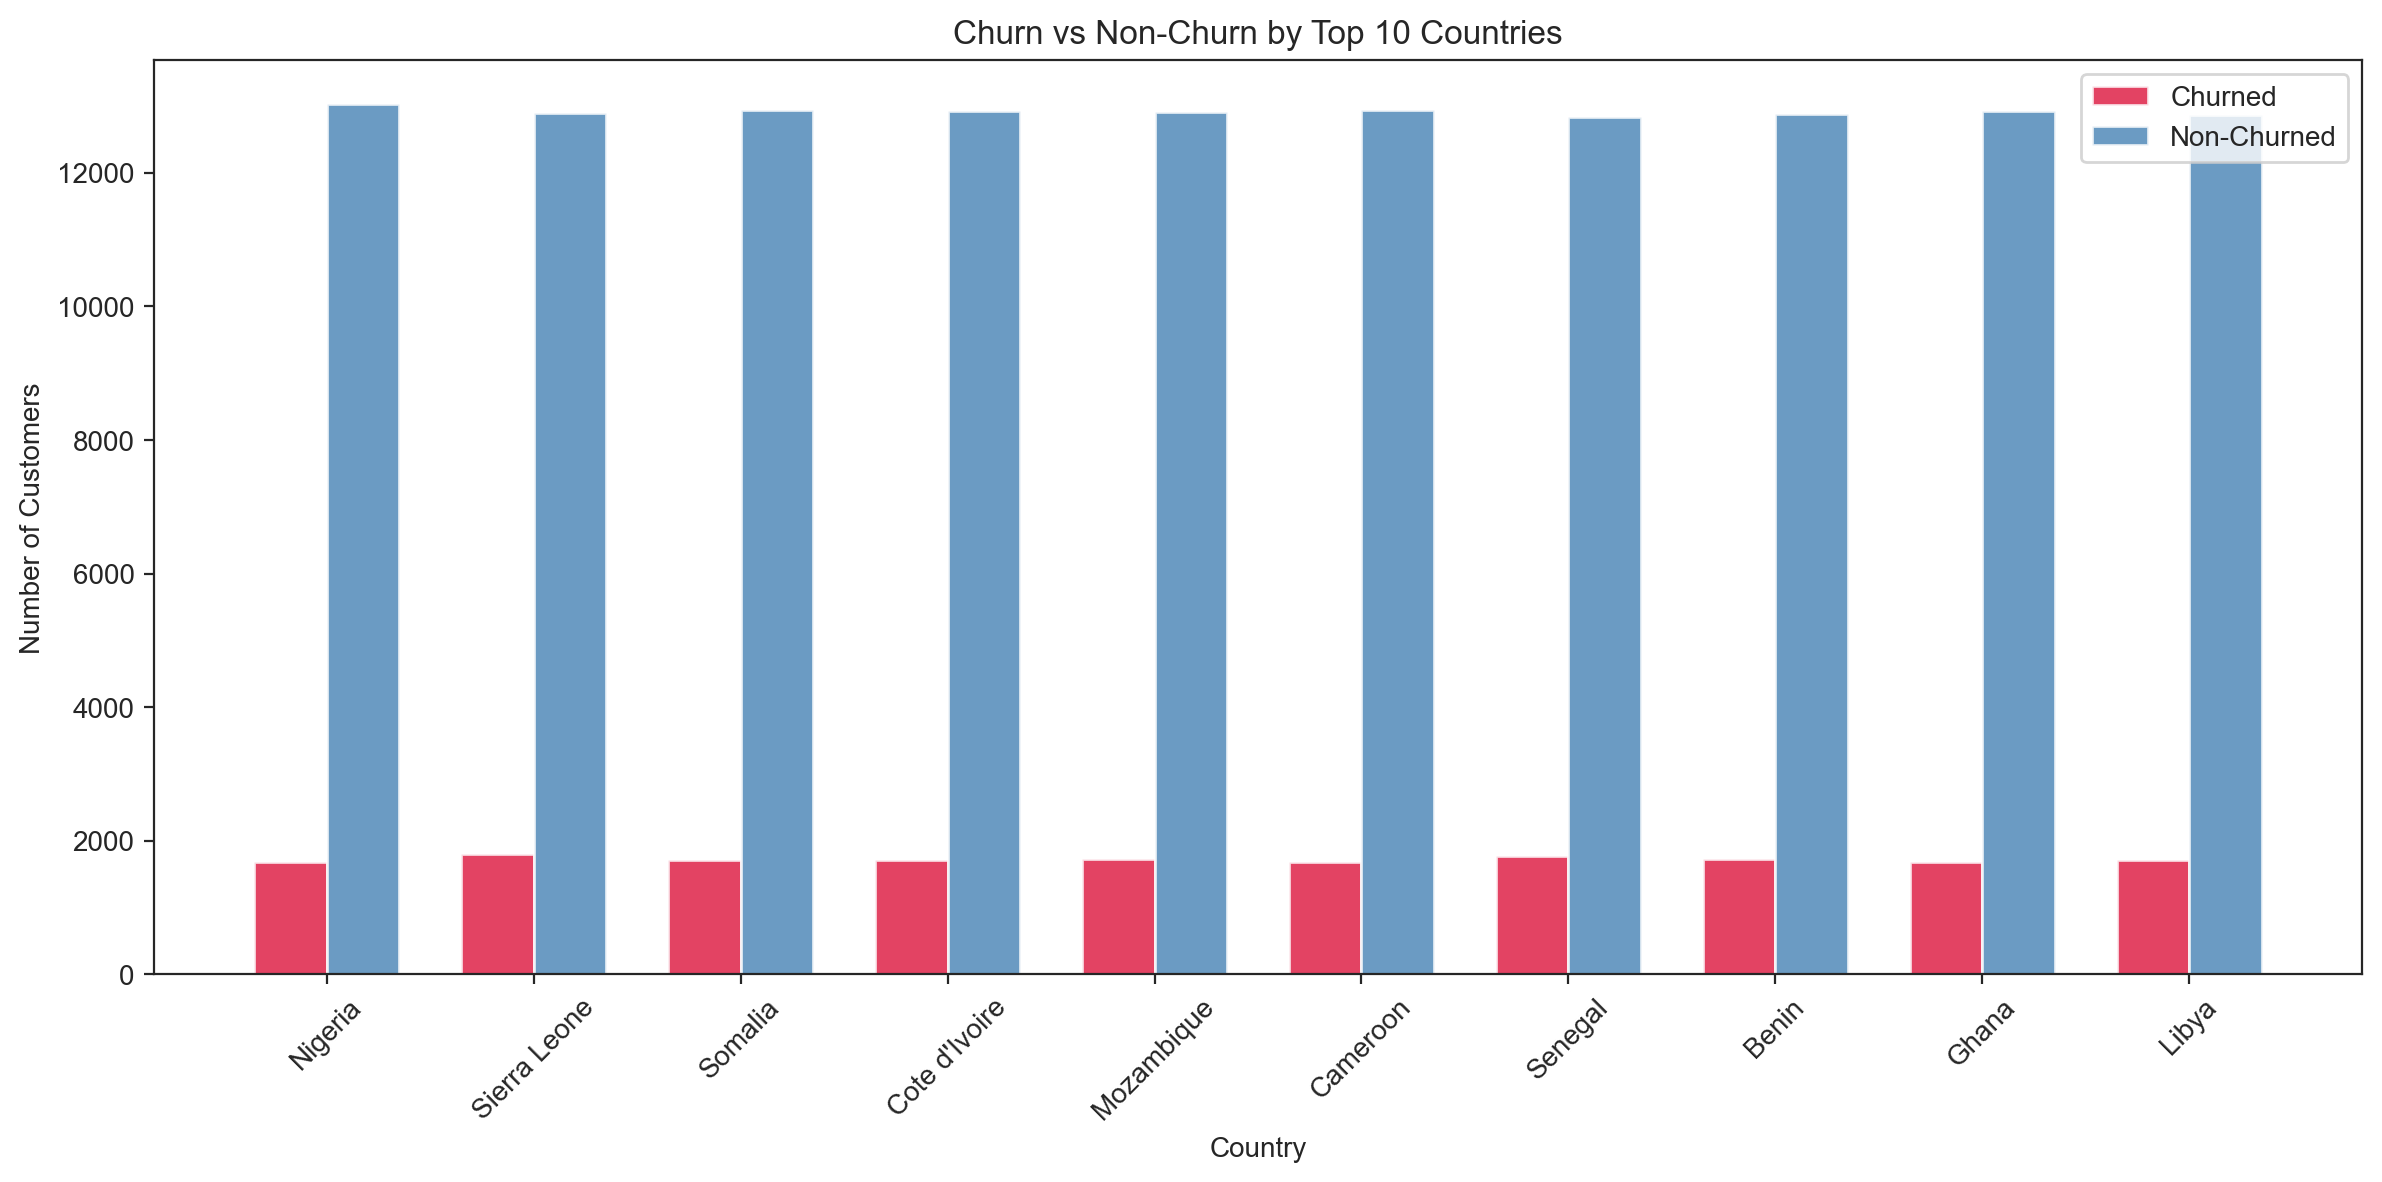

In [148]:
# Group and count customers per country
churned_demographics = churned_customers.groupby('Country')['CustomerID'].count()
non_churned_demographics = non_churned_customers.groupby('Country')['CustomerID'].count()

# Combine and sum for total customers per country
total_customers = churned_demographics.add(non_churned_demographics, fill_value=0)

# Select top 10 countries with the most customers
top_10_countries = total_customers.sort_values(ascending=False).head(10).index

# Filter both churned and non-churned to only top 10 countries
churned_top10 = churned_demographics.reindex(top_10_countries, fill_value=0)
non_churned_top10 = non_churned_demographics.reindex(top_10_countries, fill_value=0)

# Plot side-by-side bar chart
import numpy as np
x = np.arange(len(top_10_countries))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, churned_top10, width, label='Churned', color='crimson', alpha=0.8)
plt.bar(x + width/2, non_churned_top10, width, label='Non-Churned', color='steelblue', alpha=0.8)

plt.xticks(x, top_10_countries, rotation=45)
plt.xlabel('Country')
plt.ylabel('Number of Customers')
plt.title('Churn vs Non-Churn by Top 10 Countries')
plt.legend()
plt.tight_layout()
plt.show()

### The number of customers churned by Country were smaller compared to non churned across the Top 10 Countries